## Myopic trajectories (no endpoint)

In [767]:
# ~~~~ Imports ~~~~
import os, random, glob
import math
import pickle, json
import numpy as np, pandas as pd, torch
import torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
# from examples import utils
# from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import seaborn as sns
from scipy.stats import gaussian_kde, dirichlet
from scipy.signal import savgol_filter, convolve
from sklearn.isotonic import IsotonicRegression
from sklearn.neighbors import NearestNeighbors
from sklearn.manifold import TSNE
from itertools import permutations, combinations, product
from openTSNE import TSNE as oTSNE

# ~~~~ Environment setup ~~~~
device = torch.device('cpu')
print(f"Using device: {device}")

SEED = 29
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":16:8"

from VAE_model_architectures import *

def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True)

set_seed(SEED)

run_where = 'local'

# ~~~~ Configuration ~~~~
class Config:
    if run_where == 'great-lakes':
        BASE_DIR = "/nfs/turbo/umms-kaczoro/u19-shared/vae-HC-PFC/14mon_ADBXD_joined/"
        MODEL_PATH = os.path.join(BASE_DIR, "seed_model/C-GMVAE_SEED_38/saved_model_epoch20000.pth")
        GENE_CSV_PATH = "/nfs/turbo/umms-kaczoro/u19-shared/vae-HC-PFC/14mon_ADBXD_joined/input_datasets/hc_pfc_combined_rp_nor.csv"
        CFM_CSV_PATH  = "/nfs/turbo/umms-kaczoro/u19-shared/vae-HC-PFC/14mon_ADBXD_joined/input_datasets/CFC_CFM_residual_Bins_all_Strains.csv"
        LATENT_SPACE_CSV = os.path.join(BASE_DIR, "seed_model/C-GMVAE_SEED_38/latent_variables_epoch20000.csv")
        RECONS_DATA_CSV  = os.path.join(BASE_DIR, "seed_model/C-GMVAE_SEED_38/recons_cfm.csv")

    elif run_where == 'local':
        BASE_DIR = "/home/nghayes/latent-space-trajectories/"
        MODEL_PATH = os.path.join(BASE_DIR, "saved_model_epoch20000.pth")
        GENE_CSV_PATH = os.path.join(BASE_DIR, "hc_pfc_combined_rp_nor.csv")
        CFM_CSV_PATH  = os.path.join(BASE_DIR, "CFC_CFM_residual_Bins_all_Strains.csv")
        LATENT_SPACE_CSV = os.path.join(BASE_DIR, "latent_variables_epoch20000.csv")
        RECONS_DATA_CSV  = os.path.join(BASE_DIR, "recons_cfm.csv")

    GENE_COUNT = 4963
    D_in = D_out = GENE_COUNT
    LATENT_DIM = 10
    H1, H2, H3 = 128, 64, 32

    NUM_INTERPOLATION_STEPS = 24
    DENSITY_WEIGHTS = [0.1, 0.2, 0.3]
    DEFAULT_DENSITY_WEIGHT = 0.1
    NUM_PAIRS = 10
    KNN = 5
    

Using device: cpu


In [ ]:
df_gene = pd.read_csv(Config.GENE_CSV_PATH, index_col=0)

/tmp/ipykernel_52262/3916590482.py:1: DtypeWarning: Columns (0: Genotype) have mixed types. Specify dtype option on import or set low_memory=False.
  df_gene = pd.read_csv(Config.GENE_CSV_PATH, index_col=0)


In [1194]:
df_6mon = pd.read_csv('all_cells_adbxd_6mon_80perc.csv', index_col=0)

/tmp/ipykernel_52262/581532154.py:1: DtypeWarning: Columns (0: Genotype) have mixed types. Specify dtype option on import or set low_memory=False.
  df_6mon = pd.read_csv('all_cells_adbxd_6mon_80perc.csv', index_col=0)


In [1195]:
df_6mon

,0,1,2,3,4,5,6,7,8,9,...,4937,4938,barcode,subclass,cell_type,SCBID,MouseID,Age,Strain,Genotype
0,-1.271215,-0.235175,-1.311447,-0.004444,1.071280,-2.126280,0.515957,1.491095,0.833275,-0.429894,...,-0.760697,-0.674351,CK19109_GTCAAGTCAAACTCTG-1,002 IT EP-CLA Glut,glut,CK19109,2866,6,113,5
1,-0.858442,-0.839648,-0.977228,-0.921515,0.090860,1.141978,1.439929,0.327678,-0.233149,0.902286,...,-1.351918,-0.443537,CK19109_AAGTACCCAGGAGACT-1,002 IT EP-CLA Glut,glut,CK19109,2866,6,113,5
2,-2.197408,-0.547641,-0.720852,-0.577441,1.715319,1.864564,-0.960279,0.023151,-0.090509,0.767240,...,-0.669902,-0.785169,CK19109_CTGGACGTCCGTAGGC-1,002 IT EP-CLA Glut,glut,CK19109,2866,6,113,5
3,0.194546,0.457521,-1.363814,-0.174601,-1.351975,-0.797342,-1.631484,1.719358,0.122238,-0.650961,...,-1.250158,0.083588,CK19109_CGCATAAAGCTTTGTG-1,002 IT EP-CLA Glut,glut,CK19109,2866,6,113,5
4,1.837898,0.428206,-0.653439,0.073157,2.021365,1.460421,-0.115138,0.486250,-0.134642,0.806008,...,0.775091,0.249862,CK19109_ATCGTCCTCCTTCTGG-1,002 IT EP-CLA Glut,glut,CK19109,2866,6,113,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43507,0.982755,-0.038722,0.137575,-1.291887,-1.375564,1.757648,0.326070,-0.284364,2.218416,-1.277840,...,0.603100,-1.367161,CK19094_TGTAGACAGCCGCACT-1,334 Microglia NN,Immune,CK19094,3477,6,D2,5
43508,-0.069437,0.242872,-2.835331,-0.461959,0.209971,1.524473,1.071362,-0.230482,-1.180936,0.354022,...,1.052895,-1.454539,CK19094_GATTCTTGTCGAGTGA-1,334 Microglia NN,Immune,CK19094,3477,6,D2,5
43509,0.578616,0.151465,-1.498967,0.211298,0.050112,0.333166,0.101390,-0.640287,0.529046,-0.943820,...,-0.749579,0.849964,CK19094_ACTCCCACACGTCGTG-1,334 Microglia NN,Immune,CK19094,3477,6,D2,5
43510,0.327226,0.051247,-0.597383,-0.596582,-0.774276,-0.473817,-0.302355,-0.256960,-0.791473,-1.584595,...,0.873970,0.313558,CK19094_TCATTGTGTGTCCTAA-1,334 Microglia NN,Immune,CK19094,3477,6,D2,5


In [51]:
# ~~~~ Data Loading ~~~~
class MouseGeneDataset(Dataset):
    def __init__(self, df, dim_count=4842, device='cpu'): 
        self.dim_count = dim_count
        self.device = device
        self.x, self.R_S_label, self.cfm = self._process(df)
        self.len = self.x.shape[0]

    def _standardize(self, array):
        return (array - np.mean(array)) / np.std(array)

    def _process(self, df):
        #print(df.columns[-20:])
        x = df.iloc[:, :self.dim_count].values.astype('float32')
        R_S_label = df['14-6-Bin'].values
        cfm = self._standardize(df['14-6-residual'].values)

        return (
            torch.tensor(x).to(self.device),
            torch.tensor(R_S_label).to(self.device),
            torch.tensor(cfm).to(self.device)
        )

    def __getitem__(self, index):
        return self.x[index], self.R_S_label[index], self.cfm[index]

    def __len__(self):
        return self.len


_g = torch.Generator().manual_seed(SEED)

def load_mouse_gene_data(path_gene_csv, path_cfm_csv, dim_count=4842, device='cpu',
                         batch_size=512, shuffle=False, generator=_g):
    df = pd.read_csv(path_gene_csv, index_col=0, dtype={'Strain': str})
    print("Last 20 column names:"); print(df.columns[-20:])
    df = df.sample(frac=1, random_state=42)
    dataset = MouseGeneDataset(df, dim_count=dim_count, device=device)

    def _seed_worker(worker_id):
        worker_seed = SEED + worker_id
        np.random.seed(worker_seed); random.seed(worker_seed); torch.manual_seed(worker_seed)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=shuffle,
                        num_workers=0, worker_init_fn=_seed_worker, generator=generator)
    return dataloader, dataset

dataloader, train_set = load_mouse_gene_data(
    path_gene_csv=Config.GENE_CSV_PATH,
    path_cfm_csv=Config.CFM_CSV_PATH,
    dim_count=Config.GENE_COUNT,
    device=device,
    batch_size=512,
    generator=_g)

print("Total samples in dataset:", len(train_set))
print("Shape of one data point:", train_set[0][0].shape)
print("Label of first sample (R/S):", train_set[0][1].item())
print("CFM of first sample:", train_set[0][2].item())

# ~~~~ Model Setup ~~~~

class Autoencoder_CGMVAE(nn.Module):
    #C-GMVAE VAE with GMM prior and conditional layer
    def __init__(self, D_in, D_out, H1=128, H2=64, H3=32, dim_code=10, num_gaussian = 4):
        #Encoder
        super(Autoencoder_CGMVAE, self).__init__()
        self.dim_code = dim_code
        self.num_gaussian = num_gaussian
        self.label = nn.Embedding(num_gaussian, 1)
        self.encoder1 = nn.Sequential(
            nn.Linear(D_in+2, H1),
            nn.BatchNorm1d(H1),
            nn.Sigmoid(),
            nn.Linear(H1,H2),
            nn.BatchNorm1d(H2),
            nn.Sigmoid(),
            nn.Linear(H2,H3),
            nn.BatchNorm1d(H3),
            nn.Sigmoid())
    
        self.mu = nn.Sequential(nn.Linear(H3, out_features = num_gaussian*dim_code))
                            
        self.logsigma = nn.Sequential(nn.Linear(H3, out_features = num_gaussian*dim_code))
        
        self.decoder = nn.Sequential(
            nn.Linear(dim_code+1, H3),
            nn.Sigmoid(),
            nn.BatchNorm1d(H3),
            nn.Linear(H3,H2),
            nn.Sigmoid(),
            nn.BatchNorm1d(H2),
            nn.Linear(H2,H1),
            nn.Sigmoid(),
            nn.BatchNorm1d(H1),
            nn.Linear(H1,D_out+1),
            nn.Sigmoid(),
            nn.BatchNorm1d(D_out+1))
        
    def gaussian_sampler(self, mu, logsigma, y):
        y = y.long().view(-1)
        batch_size = y.shape[0]
        mu_k = mu[torch.arange(batch_size), y]  
        sigma_k = torch.exp(0.5 * logsigma[torch.arange(batch_size), y])
        eps = torch.randn_like(sigma_k)
        z = mu_k + eps * sigma_k
        return mu_k, sigma_k, z
        
    def encode(self, x, y, cfm):
        cfm = cfm.view(cfm.size(0),1)
        if x.dtype != cfm.dtype:
            cfm = cfm.to(x.dtype)
        x = torch.cat((x, cfm), dim=1)
        y_emb = self.label(y)
        y_emb = y_emb.view(y_emb.size(0),1)
        x = torch.cat((x, y_emb), dim=1)
        x = self.encoder1(x)
        mu, logsigma = self.mu(x).view(-1, self.num_gaussian, self.dim_code), self.logsigma(x).view(-1, self.num_gaussian, self.dim_code) 
        mu, logsigma, z = self.gaussian_sampler(mu, logsigma, y)
        return mu, logsigma, z
    
    def decode(self, x, y):
        y_emb = self.label(y)
        y_emb = y_emb.view(y_emb.size(0),1)
        x = torch.cat((x, y_emb), dim=1)
        reconstruction = self.decoder(x)
        return reconstruction
    
    def forward(self, x, y, cfm):
        cfm = cfm.view(cfm.size(0),1)
        if x.dtype != cfm.dtype:
            cfm = cfm.to(x.dtype)
        x = torch.cat((x, cfm), dim=1)
        y_emb = self.label(y)
        y_emb = y_emb.view(y_emb.size(0),1)
        x = torch.cat((x, y_emb), dim=1)
        x = self.encoder1(x)
        mu, logsigma = self.mu(x).view(-1, self.num_gaussian, self.dim_code), self.logsigma(x).view(-1, self.num_gaussian, self.dim_code) 
        mu, logsigma, z = self.gaussian_sampler(mu, logsigma,y)
        u = torch.cat((z, y_emb), dim=1)
        reconstruction = self.decoder(u)
        return mu, logsigma, z, reconstruction

D_in = D_out = 4842
H1, H2, H3, latent_dim = 128, 64, 32, 10

model = Autoencoder_CGMVAE(D_in, D_out, H1, H2, H3, latent_dim).to(device)
model = torch.load(Config.MODEL_PATH, map_location=device, weights_only=False)
model.to(device)
print("Model loaded.")


Last 20 column names:
Index(['4955', '4956', '4957', '4958', '4959', '4960', '4961', '4962',
       'barcode', 'subclass', 'cell_type', 'SCBID', 'MouseID', 'Age', 'Strain',
       'Genotype', 'CFM_14_5_snRNA', '14-6-residual', '14-6-Bin', 'region'],
      dtype='str')
Total samples in dataset: 56650
Shape of one data point: torch.Size([4963])
Label of first sample (R/S): 2
CFM of first sample: 0.3660229864058505
Model loaded.


In [52]:
# Loading functions and variables I need from original trajectory method

# ~~~~ Latent Space Data ~~~~
df_latent = pd.read_csv(Config.LATENT_SPACE_CSV, index_col=0)
print(df_latent['14-6-Bin'].value_counts())
print(df_latent.describe())
print(df_latent)
cols = list(df_latent.columns[:Config.LATENT_DIM]) + ["14-6-Bin"] # only want 10 LVs + which bin each observation is in
df_latent = df_latent[cols].copy()
df_latent.columns = [f"z_{i+1}" for i in range(Config.LATENT_DIM)] + ["label"] # changing names of columns: bin is now label?

df_recons = pd.read_csv(Config.RECONS_DATA_CSV)
df_recons = df_recons.loc[df_recons['epoch'] == 20000] # I added this to choose last epoch
df_latent['decoded_cfm'] = df_recons['cfm'].values # creating new column with decoded cfm values from recons csv

def decode_cfm_along_trajectory(model, trajectory_z, trajectory_labels, device='cpu'):
    """
    Decode the latent trajectory to get reconstructed CFM values.

    Args:
        model: The full model with .decode(z, y)
        trajectory_z (np.ndarray): Array of shape [steps, latent_dim]
        trajectory_labels (np.ndarray): Array of shape [steps] or [steps, label_dim]
        device (str): Device to run model on

    Returns:
        np.ndarray: Reconstructed CFM values (shape: [steps])
    """
    model.eval()

    # z tensor is list of trajectory coordinates and y tensor is list of labels?
    z_tensor = torch.tensor(trajectory_z, dtype=torch.float32).to(device)

    # If labels are not already one-hot or embedded, just use as is
    if isinstance(trajectory_labels[0], (np.integer, int)):
        y_tensor = torch.tensor(trajectory_labels, dtype=torch.long).to(device)
    else:
        y_tensor = torch.tensor(trajectory_labels, dtype=torch.float32).to(device)

    with torch.no_grad(): # without gradient calculation?
        decoded = model.decode(z_tensor, y_tensor) # shape: [steps, output_dim]
        cfm_values = decoded[:, -1].cpu().numpy() # last column = predicted CFM

    return cfm_values

all_interpolations = {}
latent_space = df_latent[[f'z_{j+1}' for j in range(Config.LATENT_DIM)]].values.astype('float32')
decoded_cfm_all = df_latent["decoded_cfm"].values # numpy array

cfm_csv_path=Config.CFM_CSV_PATH
df_cfm = pd.read_csv(cfm_csv_path)
mean_cfm = df_cfm['CFM_14_5_snRNA'].mean()
std_cfm  = df_cfm['CFM_14_5_snRNA'].std()

14-6-Bin
2    20105
3    13668
1    11443
0    11434
Name: count, dtype: int64
                LV1           LV2           LV3           LV4           LV5  \
count  56650.000000  56650.000000  56650.000000  56650.000000  56650.000000   
mean     -20.256705    -15.159655    -11.679939     -6.995157     -1.338052   
std        8.119472      7.786041      9.916827     10.911846     11.390052   
min      -34.214813    -29.359503    -27.684828    -25.183409    -21.168283   
25%      -27.479808    -21.779699    -20.591530    -15.195161     -9.749770   
50%      -20.592559    -14.820463    -12.114686     -7.309843     -0.326291   
75%      -13.231291     -8.528811     -3.410012      0.348975      7.869470   
max       -5.473288     -1.340881      5.552579     12.048773     16.966198   

                LV6           LV7           LV8           LV9          LV10  \
count  56650.000000  56650.000000  56650.000000  56650.000000  56650.000000   
mean       1.713566      6.359805     10.704072    

/tmp/ipykernel_52262/2052776025.py:12: DtypeWarning: Columns (0: epoch) have mixed types. Specify dtype option on import or set low_memory=False.
  df_recons = pd.read_csv(Config.RECONS_DATA_CSV)


In [1113]:
# only go in direction of increasing density?
# need to define log density gradient again
# may be slightly different because of piecewise KDE

# Trajectory ideas:
# At each point on trajectory, need to know what bin it's in
# Based on bin, choose correct KDE (but what if step would take me into other bin?)

def log_density(z_point, kde, eps=1e-9):
    """
    Compute log-density at a point using KDE.
    
    Args:
        z_point (np.ndarray): A single latent point (shape: [latent_dim,] or [latent_dim, 1]).
        kde (gaussian_kde): Fitted KDE object on the latent space.
        eps (float): Small value to avoid log(0).

    Returns:
        float: log-density at the point.
    """
    z_point = z_point.reshape(-1, 1)  # Ensure correct shape for KDE
    density_val = kde(z_point)[0]
    # print('density_val = ',density_val)
    # print('log-density =', np.log(density_val + eps))
    return np.log(density_val + eps)


def numerical_log_density_gradient(z_point, kde, epsilon=1e-4):
    """
    Estimate the gradient of log-density at a point using central difference.

    Args:
        z_point (np.ndarray): Point in latent space.
        kde (gaussian_kde): KDE fitted on latent space.
        epsilon (float): Small perturbation for numerical gradient.

    Returns:
        np.ndarray: Estimated gradient vector of same shape as z_point.
    """
    grad = np.zeros_like(z_point)
    for j in range(len(z_point)):
        perturb = np.zeros_like(z_point)
        perturb[j] = epsilon

        ld_plus = log_density(z_point + perturb, kde)
        ld_minus = log_density(z_point - perturb, kde)
        grad[j] = (ld_plus - ld_minus) / (2.0 * epsilon)

        # print('ld_plus =', ld_plus)
        # print('ld_minus =', ld_minus)
        # print('gradient this index =', grad[j])

    return grad

def density_guided_interpolation(
    start_point,
    end_point,
    latent_space,
    steps,
    step_size,
    density_weight=0.8,
    log_density_drop_threshold=0.5,
    min_step_size=1e-2
):
    """
    Generate an interpolation path in latent space guided by KDE density.

    Args:
        start_point (np.ndarray): Starting latent vector.
        end_point (np.ndarray): Target latent vector.
        latent_space (np.ndarray): All latent vectors from data (for KDE fitting).
        steps (int): Number of interpolation steps.
        step_size (float): Base step size.
        density_weight (float): Weight of density gradient vs. target direction.
        log_density_drop_threshold (float): Threshold for reducing step size if moving into low-density region.
        min_step_size (float): Minimum allowed step size.

    Returns:
        np.ndarray: Interpolated latent path (shape: [steps + 2, latent_dim]).
    """
    kde = gaussian_kde(latent_space.T)  # Fit KDE on training latent space

    path = [start_point]
    current_point = start_point.copy()

    for _ in range(steps):
        cur_step_size = step_size

        # Direction toward the goal
        target_dir = end_point - current_point
        target_norm = np.linalg.norm(target_dir)
        if target_norm > 0:
            target_dir /= target_norm

        # Direction toward denser region
        density_grad = numerical_log_density_gradient(current_point, kde)
        grad_norm = np.linalg.norm(density_grad)
        if grad_norm > 0:
            density_grad /= grad_norm

        # Weighted blend of directions
        move_dir = (1.0 - density_weight) * target_dir + density_weight * density_grad
        move_norm = np.linalg.norm(move_dir)
        if move_norm > 0:
            move_dir /= move_norm

        # Propose next step
        proposed_next_point = current_point + move_dir * cur_step_size

        # Adjust step size if moving into much lower-density region
        current_log_dens = log_density(current_point, kde)
        next_log_dens = log_density(proposed_next_point, kde)

        if next_log_dens < current_log_dens - log_density_drop_threshold:
            cur_step_size = max(cur_step_size * 0.9, min_step_size)
            # print('decreasing step size = ', cur_step_size)

        # Finalize step
        next_point = current_point + move_dir * cur_step_size
        path.append(next_point)
        current_point = next_point

    # Add final target point explicitly
    path.append(end_point)
    return np.array(path)



In [969]:
df_latent

,z_1,z_2,z_3,z_4,z_5,z_6,z_7,z_8,z_9,z_10,label,decoded_cfm,density_bin
0,-24.256855,-18.943563,-19.148005,-13.069660,-7.281853,-6.647669,-1.973320,1.312754,5.479063,10.920240,2,1.048495,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]"
1,-32.498856,-27.973068,-25.985146,-23.571732,-19.487030,-15.888780,-14.033054,-9.226448,-8.665678,-4.734122,3,1.236806,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"
2,-17.562922,-16.157148,-7.969545,-5.897250,1.853780,4.455924,9.762284,14.726957,23.734491,29.096786,2,1.044764,"[2, 1, 2, 2, 2, 2, 2, 2, 2, 2]"
3,-28.858011,-24.174309,-22.691444,-19.941648,-16.066748,-12.556651,-10.494271,-5.782712,-5.136093,-1.035175,3,-0.825561,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"
4,-10.571421,-6.463661,0.640753,7.082870,11.920109,17.315226,24.198599,28.219280,36.607440,41.267610,0,0.690024,"[3, 3, 3, 3, 3, 3, 3, 3, 3, 3]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
56645,-28.579952,-23.901604,-22.118683,-19.591473,-15.684873,-12.046993,-10.108648,-5.416104,-4.710186,-0.721344,3,0.267969,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"
56646,-7.582398,-3.366018,3.963249,10.430345,15.107400,20.847500,27.655052,31.937830,40.201540,44.993100,0,-0.972245,"[3, 3, 3, 3, 3, 3, 3, 3, 3, 3]"
56647,-17.119564,-13.705447,-7.196110,-4.540887,3.223161,5.727212,10.905486,15.751303,24.399230,29.637558,2,0.547159,"[2, 2, 2, 2, 2, 2, 2, 2, 2, 2]"
56648,-29.270935,-24.531736,-22.611712,-20.303423,-16.054407,-12.572237,-10.648892,-5.845601,-5.259646,-1.332067,3,1.229240,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"


## Attempting to fit unimodal KDE to points in each QRT bin (by label - not spatially constrained)

### Fit 4 KDEs

In [996]:
# create subsets of latent_space numpy array for each bin
latent_space_bin0 = df_latent[df_latent['label'] == 0][[f'z_{j+1}' for j in range(Config.LATENT_DIM)]].values.astype('float32')
latent_space_bin1 = df_latent[df_latent['label'] == 1][[f'z_{j+1}' for j in range(Config.LATENT_DIM)]].values.astype('float32')
latent_space_bin2 = df_latent[df_latent['label'] == 2][[f'z_{j+1}' for j in range(Config.LATENT_DIM)]].values.astype('float32')
latent_space_bin3 = df_latent[df_latent['label'] == 3][[f'z_{j+1}' for j in range(Config.LATENT_DIM)]].values.astype('float32')

In [ ]:
kde_bin0_qrt = gaussian_kde(latent_space_bin0.T)
kde_bin1_qrt = gaussian_kde(latent_space_bin1.T)
kde_bin2_qrt = gaussian_kde(latent_space_bin2.T)
kde_bin3_qrt = gaussian_kde(latent_space_bin3.T)

In [1019]:
df_latent['label'].sort_values().unique()

array([0, 1, 2, 3])

In [1109]:
# later can directly save these to a list without saving individual objects
latent_space_qrt_bins = [latent_space_bin0, latent_space_bin1, latent_space_bin2, latent_space_bin3]
kde_qrt_bins = [kde_bin0_qrt, kde_bin1_qrt, kde_bin2_qrt, kde_bin3_qrt]

# record weights of each kde (by relative proportion of all points) to normalize
kde_qrt_weights = [len(latent_space_bin0)/len(latent_space),
len(latent_space_bin1)/len(latent_space),
len(latent_space_bin2)/len(latent_space),
len(latent_space_bin3)/len(latent_space)]

In [1201]:
kde_single = gaussian_kde(latent_space.T)

In [1210]:
# compute log-likelihood of KDE (single)

ll_kde_single = 0

for point in latent_space:
    ll_kde_single += np.log(kde_single(point)[0])

In [1211]:
ll_kde_single

np.float64(-246130.9723020975)

In [1209]:
kde_qrt_bins

In [1227]:
def evaluate_kde_mixture(z_point, kde_list, kde_weights):

    kde_evaluate = 0

    for i in range(len(kde_list)):
        kde_evaluate += (kde_weights[i])*(kde_list[i](z_point)[0])

    return kde_evaluate

In [1213]:
evaluate_kde_mixture(latent_space[0], kde_qrt_bins, kde_qrt_weights)

np.float64(0.013575865605668687)

In [1235]:
kde_qrt_bins[3](latent_space[1])[0]

np.float64(58143.72877359623)

In [1229]:
for i in range(len(latent_space)):
    point = latent_space[i,:]
    if evaluate_kde_mixture(point, kde_qrt_bins, kde_qrt_weights) > 1:
        print(i)
        print('sum of KDEs > 1!')

1
sum of KDEs > 1!
3
sum of KDEs > 1!
4
sum of KDEs > 1!
5
sum of KDEs > 1!
6
sum of KDEs > 1!
7
sum of KDEs > 1!
8
sum of KDEs > 1!
11
sum of KDEs > 1!
12
sum of KDEs > 1!
13
sum of KDEs > 1!
14
sum of KDEs > 1!
15
sum of KDEs > 1!
16
sum of KDEs > 1!
18
sum of KDEs > 1!
24
sum of KDEs > 1!
25
sum of KDEs > 1!
26
sum of KDEs > 1!
27
sum of KDEs > 1!
30
sum of KDEs > 1!
31
sum of KDEs > 1!
35
sum of KDEs > 1!
37
sum of KDEs > 1!
39
sum of KDEs > 1!
41
sum of KDEs > 1!
42
sum of KDEs > 1!
43
sum of KDEs > 1!
44
sum of KDEs > 1!
45
sum of KDEs > 1!
46
sum of KDEs > 1!
47
sum of KDEs > 1!
48
sum of KDEs > 1!
50
sum of KDEs > 1!
51
sum of KDEs > 1!
53
sum of KDEs > 1!
56
sum of KDEs > 1!
57
sum of KDEs > 1!
60
sum of KDEs > 1!
61
sum of KDEs > 1!
62
sum of KDEs > 1!
63
sum of KDEs > 1!
64
sum of KDEs > 1!
66
sum of KDEs > 1!
67
sum of KDEs > 1!
68
sum of KDEs > 1!
71
sum of KDEs > 1!
73
sum of KDEs > 1!
74
sum of KDEs > 1!
78
sum of KDEs > 1!
80
sum of KDEs > 1!
81
sum of KDEs > 1!
82
sum 

KeyboardInterrupt: 

In [1237]:
# compute log-likelihood of mixture of KDEs

ll_kde_mixture = 0

for point in latent_space:
    ll_kde_mixture += np.log(evaluate_kde_mixture(point, kde_qrt_bins, kde_qrt_weights))

In [1221]:
ll_kde_mixture

np.float64(3878.1564949373887)

In [ ]:
# function to find density gradient at any point using 4 KDEs for QRT bins

def gradient_multiple_kdes(z_point, kde_list, kde_weights, epsilon=1e-4):
    '''
    Compute gradient of log-density for multiple KDEs at once (e.g., mixture)

    Args:
        z_point (np.ndarray): Point in latent space.
        kde_list (list of gaussian_kde objects): set of kdes, each fit on some subset of latent space data
        kde_weights (list of floats): relative weights of kde data subsets (for normalization)
        epsilon (float): Small perturbation for numerical gradient.
    
    Returns:
        grad_all = np.ndarray: Estimated gradient vector of same shape os z_point.
    '''

    grad_list = []
    # maybe weighting isn't that good

    # future: make it so kde dict works as well as list?
    for i in range(len(kde_list)):
        grad = numerical_log_density_gradient(z_point, kde_list[i], epsilon)
        print(grad)
        grad_list.append(kde_weights[i]*grad)
    
    grad_all = sum(grad_list)

    return grad_all



In [1120]:
kde_qrt_weights

[0.20183583406884378,
 0.2019947043248014,
 0.35489849955869374,
 0.24127096204766108]

In [1124]:
gradient_multiple_kdes(latent_space[4], kde_qrt_bins, kde_qrt_weights)

[-44.54357    51.827114   22.941504    5.7614455 -15.549615  -27.46341
  -5.0650764   2.7449179  -3.2364542  13.044945 ]
[ 14.25652   -16.959398   11.104097  -14.7766     -1.2598926  -6.290897
  10.795199   15.385828  -33.4645     19.047823 ]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


array([-6.1107473,  7.0348606,  6.8733864, -1.8219286, -3.3929613,
       -6.8138285,  1.158259 ,  3.6618786, -7.412884 ,  6.4804964],
      dtype=float32)

### Find max and argmax of each KDE

In [1028]:
# find what max KDE value is in each bin
kde_qrt_argmaxes = []
kde_qrt_maxes = []

for qrt_bin in df_latent['label'].sort_values().unique():
    print('QRT bin = ', qrt_bin)

    max_kde_val = 0

    for point in latent_space_qrt_bins[qrt_bin]:
        if kde_qrt_bins[qrt_bin](point) > max_kde_val:
            max_kde_val = kde_qrt_bins[qrt_bin](point)[0]
            location_of_max = point

    kde_qrt_argmaxes.append(location_of_max)
    kde_qrt_maxes.append(max_kde_val)
    print('max kde value = ', max_kde_val)
    print('point that maximizes kde = ', location_of_max, '\n')

QRT bin =  0
max kde value =  8814531.037936937
point that maximizes kde =  [-9.303444  -5.0807853  2.0082877  8.535408  13.484655  18.727152
 25.690115  29.938284  38.08124   43.006157 ] 

QRT bin =  1
max kde value =  152.62877370072027
point that maximizes kde =  [-16.280678  -11.100415   -7.030626   -3.370542    4.373686    6.9463205
  12.093964   16.806915   25.218037   30.447584 ] 

QRT bin =  2
max kde value =  2.0302578282080397
point that maximizes kde =  [-19.479803  -12.99931    -9.129271   -4.96248     2.627885    5.1916504
  10.399362   15.050638   23.424646   28.520697 ] 

QRT bin =  3
max kde value =  654169.8227569277
point that maximizes kde =  [-30.269844  -25.74693   -23.780073  -21.496922  -17.590033  -13.936008
 -12.107115   -7.3824763  -6.7834396  -2.8394837] 



### Compare empirical density in box to integral of KDE over that box
NOTE: this is SLOW, most likely not best way to assess fit, but decent to get an idea for single small areas

In [1061]:
# how to check element-wise comparison for list or tuple
a = (1,2,3)
b = (4,5,6)
c = (7,1,9)

all(x < y for x, y in zip(a, b))

True

In [1062]:
# check element-wise comparison for numpy array
a = np.array(a)
b = np.array(b)
c = np.array(c)

print((a < b).all())

if (a<b).all() and (b<c).all():
    print(True)

True


In [1197]:
# make bins centered at each of the argmaxes
delta = 0.5 # don't know what best is

box_center = kde_qrt_argmaxes[0]
box_lower_limits = box_center - delta/2
box_upper_limits = box_center + delta/2

num_points_in_box = 0

for point in latent_space_qrt_bins[0]: # could also go through all points, but right now want to check fit of kde
    if (point > box_lower_limits).all() and (point < box_upper_limits).all():
        print('this point is in the box!!')
        num_points_in_box += 1

print('number of points in box = ', num_points_in_box)
print('density in box = ', num_points_in_box/len(latent_space_qrt_bins[0]))


this point is in the box!!
this point is in the box!!
this point is in the box!!
this point is in the box!!
this point is in the box!!
this point is in the box!!
this point is in the box!!
this point is in the box!!
this point is in the box!!
this point is in the box!!
this point is in the box!!
this point is in the box!!
this point is in the box!!
this point is in the box!!
this point is in the box!!
this point is in the box!!
this point is in the box!!
this point is in the box!!
this point is in the box!!
this point is in the box!!
this point is in the box!!
this point is in the box!!
this point is in the box!!
this point is in the box!!
this point is in the box!!
this point is in the box!!
this point is in the box!!
this point is in the box!!
this point is in the box!!
this point is in the box!!
this point is in the box!!
this point is in the box!!
this point is in the box!!
this point is in the box!!
this point is in the box!!
this point is in the box!!
this point is in the box!!
t

In [1198]:
box_lower_limits

array([-9.553444 , -5.3307853,  1.7582877,  8.285408 , 13.234655 ,
       18.477152 , 25.440115 , 29.688284 , 37.83124  , 42.756157 ],
      dtype=float32)

In [1079]:
kde_qrt_bins[0].integrate_box(box_lower_limits, box_upper_limits)

np.float64(0.029056448274313564)

### Try to sample points in space and compare KDE values with "true" density values
Requires estimating "true" value at that point - can use something similar to paper

Have to choose size of interval/neighborhood strategically

In [1087]:
# from google, check this lol

def n_sphere_volume(n: int, radius: float = 1.0) -> float:
    """
    Computes the exact analytical volume of an n-dimensional sphere.
    
    Parameters:
    n (int): The dimension of the sphere.
    radius (float): The radius of the sphere (defaults to 1.0).
    """
    if n < 0:
        raise ValueError("Dimension must be a non-negative integer.")
        
    # Standard formula using the math.gamma function
    numerator = (math.pi ** (n / 2)) * (radius ** n)
    denominator = math.gamma((n / 2) + 1)
    
    return numerator / denominator

In [1099]:
# Choose a point in domain of KDE

density_test_point = kde_qrt_argmaxes[0]
bandwidth = kde_bin0_qrt.covariance_factor() # THIS SEEMS TO GIVE ME BANDWIDTH?

# what is bandwidth of kde? how far do I need to look? - I have this now
# can also kde.resample([size, seed]) to get sample of points from kde

num_points_in_neighborhood = 0

for point in latent_space_bin0:
    if np.linalg.norm(point - density_test_point) < bandwidth/4:
        num_points_in_neighborhood += 1

print('number of points in neighborhood = ', num_points_in_neighborhood)
print('f(x) value = ', num_points_in_neighborhood/(len(latent_space_bin0)*n_sphere_volume(10, bandwidth/4)))
# check volume element: this is probably wrong
print('KDE value = ', kde_bin0_qrt(density_test_point)[0])
# what is radius of this cluster???

number of points in neighborhood =  23
f(x) value =  655049.9764108219
KDE value =  8814531.037936937


In [1083]:
# compute bandwidth using Scott's rule
len(latent_space_bin0)**(-1./(10+4))

0.5130133902638648

In [1328]:
# Create an empirical data density distribution
# latent_space has only the coordinates of each point
# THIS METHOD DEFINES BIN SIZE AND USES THAT FOR ALL LVS - if we don't need to force bins to be hypercubes, can instead define number of bins per LV

total_num_points = len(latent_space)
print(total_num_points)
density_bin_size = 1 # this makes total number of bins 10^17
num_bins_per_dim = 14 # if we want to control number of bins rather than bin size
# 53 gives me < 550 in all bins

# option = 'control bin size'
option = 'control bin number'
# try bin = 1 at first

# store lower and upper limits of each latent dimension
lower_limits = []
upper_limits = []

# look at density counts along each LV
density_bin_counts_all = []

# I probably don't need to do this
for dim in range(latent_dim):
    latent_vals = df_latent['z_' + str(dim+1)]
    lower_limit = math.floor(np.min(latent_vals))
    upper_limit = math.ceil(np.max(latent_vals))
    lower_limits.append(lower_limit)
    upper_limits.append(upper_limit)
    print(upper_limit - lower_limit)

    if option == 'control bin size':
        num_bins = int((upper_limit - lower_limit)/density_bin_size)
    elif option == 'control bin number':
        num_bins = num_bins_per_dim

    density_bin_counts_all.append(np.zeros(num_bins, dtype=int))

# checking bins are what I expect
# density_bins = []

# left_endpoint = lower_limits[1]
# density_bin_size = (upper_limits[1] - lower_limits[1])/num_bins_per_dim
# right_endpoint = left_endpoint + density_bin_size
# while right_endpoint <= upper_limits[1]:
#     density_bin = {'low': left_endpoint, 'high': right_endpoint}
#     density_bins.append(density_bin)

#     left_endpoint += density_bin_size
#     right_endpoint += density_bin_size

# print(density_bins)

# print(lower_limits)
# print(upper_limits)

# (for now) not explicitly saving bins, can calculate based on bin size and lower/upper limits
# also (for now) not creating a gigantic array of all bins, just going to compute each time?
# lots will be zero probably

# checking that I get correct bin index (before running for all points in latent space)
# point = latent_space[2,:]
# print(point)
# for dim in range(latent_dim):
#     dist_from_lower_limit = point[dim] - lower_limits[dim]
#     print (dist_from_lower_limit)
    
#     bin_index = math.floor(dist_from_lower_limit/density_bin_size)
#     print(bin_index)

all_bins_list = []
all_bins_list_str = []

# maybe check iterating by index and calling point from latent space to make sure I'm going in order?
for point in latent_space:
    # go through all latent dims, count how many points in each bin
    # this_point_bins = np.zeros(latent_dim, dtype=int)
    this_point_bins = []
    for dim in range(latent_dim):
        dist_from_lower_limit = point[dim] - lower_limits[dim]
        # start of the kth bin is defined by lower_limit + k*density_bin_size
        # I need to determine k
        # divide by density_bin_size, will get something between two integers, take floor to get k
        if option == 'control bin size':
            bin_index = math.floor(dist_from_lower_limit/density_bin_size)
        elif option == 'control bin number':
            # first compute bin size - will not be the same for all LVs (I could also do this once earlier and then call it here 
            # so I'm not having to compute each time)
            bin_size_dim = (upper_limits[dim] - lower_limits[dim])/num_bins_per_dim
            bin_index = math.floor(dist_from_lower_limit/bin_size_dim)
        # this_point_bins[dim] = bin_index
        this_point_bins.append(bin_index)

        density_bin_counts_all[dim][bin_index] += 1
    
    all_bins_list.append(this_point_bins)
    all_bins_list_str.append(str(this_point_bins)) # originally I had this because this_point_bins was a np.array

df_latent['density_bin'] = all_bins_list
# df_latent['density_bin_str'] = all_bins_list_str # because I can get the unique values here

print(len(list(set(all_bins_list_str))))

# df_latent['density_bin_str'].unique()
df_latent['density_bin'].apply(tuple).unique() # to make hashable


56650
30
29
34
39
39
41
46
46
54
55
1774


array([(5, 5, 3, 4, 5, 3, 4, 4, 4, 4), (1, 0, 0, 0, 0, 0, 0, 0, 0, 0),
       (8, 6, 8, 7, 8, 7, 7, 8, 9, 9), ...,
       (3, 8, 3, 5, 6, 4, 5, 5, 4, 5), (10, 10, 10, 8, 10, 8, 8, 9, 9, 9),
       (5, 6, 5, 5, 6, 4, 5, 4, 5, 5)], shape=(1774,), dtype=object)

In [79]:
for i in range(latent_dim):
    print('LV' + str(i) + ': lower lim = ' + str(lower_limits[i]) + ', upper lim = ' + str(upper_limits[i]) + ', spread = ' + str(upper_limits[i] - lower_limits[i]))

LV0: lower lim = -35, upper lim = -5, spread = 30
LV1: lower lim = -30, upper lim = -1, spread = 29
LV2: lower lim = -28, upper lim = 6, spread = 34
LV3: lower lim = -26, upper lim = 13, spread = 39
LV4: lower lim = -22, upper lim = 17, spread = 39
LV5: lower lim = -18, upper lim = 23, spread = 41
LV6: lower lim = -16, upper lim = 30, spread = 46
LV7: lower lim = -12, upper lim = 34, spread = 46
LV8: lower lim = -11, upper lim = 43, spread = 54
LV9: lower lim = -7, upper lim = 48, spread = 55


In [147]:
df_latent

,z_1,z_2,z_3,z_4,z_5,z_6,z_7,z_8,z_9,z_10,label,decoded_cfm,density_bin
0,-24.256855,-18.943563,-19.148005,-13.069660,-7.281853,-6.647669,-1.973320,1.312754,5.479063,10.920240,2,1.048495,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]"
1,-32.498856,-27.973068,-25.985146,-23.571732,-19.487030,-15.888780,-14.033054,-9.226448,-8.665678,-4.734122,3,1.236806,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"
2,-17.562922,-16.157148,-7.969545,-5.897250,1.853780,4.455924,9.762284,14.726957,23.734491,29.096786,2,1.044764,"[2, 1, 2, 2, 2, 2, 2, 2, 2, 2]"
3,-28.858011,-24.174309,-22.691444,-19.941648,-16.066748,-12.556651,-10.494271,-5.782712,-5.136093,-1.035175,3,-0.825561,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"
4,-10.571421,-6.463661,0.640753,7.082870,11.920109,17.315226,24.198599,28.219280,36.607440,41.267610,0,0.690024,"[3, 3, 3, 3, 3, 3, 3, 3, 3, 3]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
56645,-28.579952,-23.901604,-22.118683,-19.591473,-15.684873,-12.046993,-10.108648,-5.416104,-4.710186,-0.721344,3,0.267969,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"
56646,-7.582398,-3.366018,3.963249,10.430345,15.107400,20.847500,27.655052,31.937830,40.201540,44.993100,0,-0.972245,"[3, 3, 3, 3, 3, 3, 3, 3, 3, 3]"
56647,-17.119564,-13.705447,-7.196110,-4.540887,3.223161,5.727212,10.905486,15.751303,24.399230,29.637558,2,0.547159,"[2, 2, 2, 2, 2, 2, 2, 2, 2, 2]"
56648,-29.270935,-24.531736,-22.611712,-20.303423,-16.054407,-12.572237,-10.648892,-5.845601,-5.259646,-1.332067,3,1.229240,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"


In [1329]:
df_latent['density_bin'].apply(tuple).value_counts()

df_density = df_latent['density_bin'].apply(tuple).value_counts().rename_axis('nonzero_bins').reset_index(name='counts')
df_density['density'] = df_density['counts']/len(latent_space)
df_density

,nonzero_bins,counts,density
0,"(12, 12, 12, 12, 12, 12, 12, 12, 12, 12)",2429,0.042877
1,"(2, 2, 1, 1, 1, 1, 1, 1, 1, 1)",2386,0.042118
2,"(11, 11, 12, 12, 12, 12, 12, 12, 12, 12)",2268,0.040035
3,"(13, 13, 13, 13, 13, 13, 13, 13, 13, 13)",1555,0.027449
4,"(0, 0, 0, 0, 0, 0, 0, 0, 0, 0)",1527,0.026955
...,...,...,...
1769,"(2, 3, 2, 2, 2, 2, 2, 2, 1, 1)",1,0.000018
1770,"(4, 3, 3, 4, 4, 3, 4, 4, 4, 4)",1,0.000018
1771,"(3, 8, 3, 5, 6, 4, 5, 5, 4, 5)",1,0.000018
1772,"(10, 10, 10, 8, 10, 8, 8, 9, 9, 9)",1,0.000018


<Axes: xlabel='counts', ylabel='Count'>

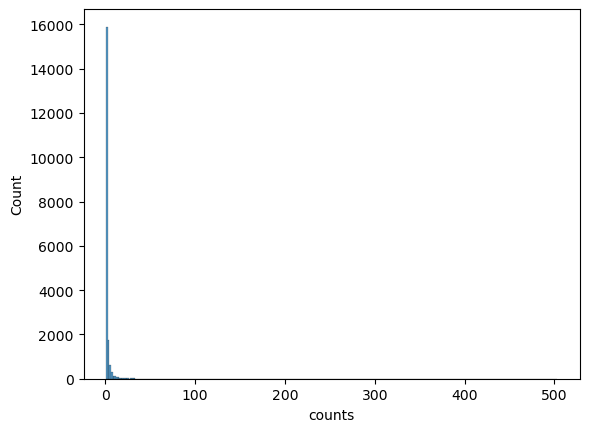

In [1268]:
sns.histplot(data=df_density, x='counts')

In [ ]:
hist_bins = list(range(0, 551, 10))
hist_bins

[0,
 10,
 20,
 30,
 40,
 50,
 60,
 70,
 80,
 90,
 100,
 110,
 120,
 130,
 140,
 150,
 160,
 170,
 180,
 190,
 200,
 210,
 220,
 230,
 240,
 250,
 260,
 270,
 280,
 290,
 300,
 310,
 320,
 330,
 340,
 350,
 360,
 370,
 380,
 390,
 400,
 410,
 420,
 430,
 440,
 450,
 460,
 470,
 480,
 490,
 500,
 510,
 520,
 530,
 540,
 550]

In [1287]:
len(df_density.index)

19324

In [1290]:
df_density.to_pickle('df_density_uniform.pkl')

<Axes: >

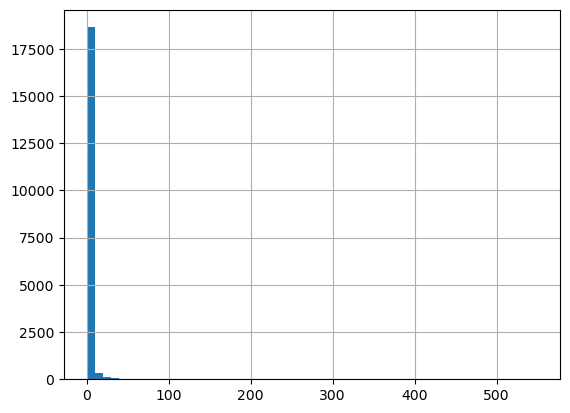

In [1285]:
df_density['counts'].hist(bins=hist_bins, density=False)

<Axes: >

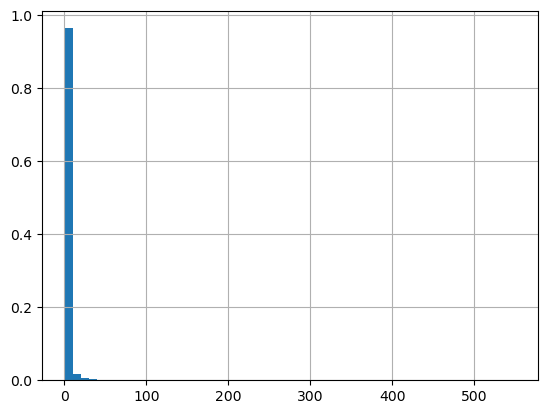

In [1289]:
df_density['counts'].hist(bins=hist_bins, weights = list(np.ones_like(df_density.index)/len(df_density.index)))

In [1257]:
df_density[df_density['counts']>1]

,nonzero_bins,counts,density
0,"(46, 46, 47, 47, 48, 48, 48, 48, 48, 48)",503,0.008879
1,"(46, 46, 47, 47, 48, 47, 48, 48, 48, 48)",411,0.007255
2,"(9, 9, 7, 7, 7, 6, 5, 6, 5, 5)",409,0.007220
3,"(47, 47, 48, 48, 49, 48, 49, 49, 49, 49)",377,0.006655
4,"(8, 8, 6, 6, 6, 5, 4, 5, 4, 4)",366,0.006461
...,...,...,...
6128,"(3, 2, 1, 1, 2, 1, 1, 1, 1, 1)",2,0.000035
6129,"(28, 26, 28, 26, 31, 28, 29, 29, 32, 33)",2,0.000035
6130,"(41, 41, 37, 35, 39, 35, 35, 36, 38, 38)",2,0.000035
6131,"(33, 34, 32, 30, 35, 31, 31, 33, 35, 35)",2,0.000035


In [1270]:
print('fraction of bins with > 1 point using uniform bins:')
print(len(df_density[df_density['counts']>1])/len(df_density))

print('average number of points over all nonempty bins:')
print(df_density['counts'].mean(), "\u00B1", df_density['counts'].std())

fraction of bins with > 1 point using uniform bins:
0.31737735458497207
average number of points over all nonempty bins:
2.931587663009729 ± 12.188890021110268


In [1330]:
# generate a point at center of each bin - ONLY ONES THAT HAVE POINTS IN THEM
# decode CFM
# num_bins_per_dim
center_bin_coords = []
for row in df_density.itertuples():
    # compute coord for each latent dimension
    this_bin_coords = []
    for dim in range(latent_dim):
        bin = row.nonzero_bins[dim]
        dim_binsize = (upper_limits[dim]-lower_limits[dim])/num_bins_per_dim
        center_coord = lower_limits[dim] + (bin + 0.5)*dim_binsize
        this_bin_coords.append(center_coord)
    center_bin_coords.append(this_bin_coords)
    

In [1310]:
(0,0,0,0,0,0,0,0,0,0) in df_density['nonzero_bins'].tolist()

False

In [1312]:
# generate a point at center of each bin - EMPTY ONES

center_bin_coords_empty = []
list_of_bins = [0,1,2,3]

all_bins = list(product(list_of_bins, repeat=10))
print(len(all_bins))

for bin in all_bins:
    # if bin has points in it - IGNORE
    # I want to keep these separate for now for easier plotting
    # I can combine them into one later by taking this if statement out
    if bin in df_density['nonzero_bins'].tolist():
        print('this bin is nonempty, skipping!', bin)
        continue

    this_bin_coords = []
    for dim in range(latent_dim):
        this_bin = bin[dim]
        dim_binsize = (upper_limits[dim]-lower_limits[dim])/num_bins_per_dim
        center_coord = lower_limits[dim] + (this_bin + 0.5)*dim_binsize
        this_bin_coords.append(center_coord)
    center_bin_coords_empty.append(this_bin_coords)

print(len(center_bin_coords_empty), len(center_bin_coords_empty[-1]))
    

1048576


KeyboardInterrupt: 

In [667]:
center_bin_coords_empty[-1]

[-8.75, -4.625, 1.75, 8.125, 12.125, 17.875, 24.25, 28.25, 36.25, 41.125]

In [575]:
latent_space

array([[-24.256855 , -18.943563 , -19.148005 , ...,   1.3127543,
          5.4790635,  10.92024  ],
       [-32.498856 , -27.973068 , -25.985146 , ...,  -9.226448 ,
         -8.665678 ,  -4.734122 ],
       [-17.562922 , -16.157148 ,  -7.969545 , ...,  14.726957 ,
         23.734491 ,  29.096786 ],
       ...,
       [-17.119564 , -13.705447 ,  -7.1961102, ...,  15.751303 ,
         24.39923  ,  29.637558 ],
       [-29.270935 , -24.531736 , -22.611712 , ...,  -5.845601 ,
         -5.2596464,  -1.3320674],
       [-24.021748 , -18.361439 , -16.596233 , ...,   3.1078653,
          7.0281296,  12.474275 ]], shape=(56650, 10), dtype=float32)

In [1313]:
np.array(center_bin_coords)

array([[ -8.67924528,  -4.55660377,   2.47169811, ...,  30.09433962,
         38.41509434,  43.33018868],
       [ -8.67924528,  -4.55660377,   2.47169811, ...,  30.09433962,
         38.41509434,  43.33018868],
       [-29.62264151, -24.80188679, -23.18867925, ...,  -6.35849057,
         -5.39622642,  -1.29245283],
       ...,
       [-22.26415094, -21.51886792, -14.8490566 , ...,   4.05660377,
          7.8490566 ,  13.23584906],
       [-26.79245283, -22.06603774, -20.62264151, ...,  -3.75471698,
         -2.33962264,   0.78301887],
       [-28.49056604, -13.85849057, -20.62264151, ...,   4.9245283 ,
          8.86792453,  15.31132075]], shape=(19324, 10))

In [689]:
np.array(center_bin_coords_empty)

array([[-31.25 , -26.375, -23.75 , ...,  -6.25 ,  -4.25 ,  13.625],
       [-31.25 , -26.375, -23.75 , ...,  -6.25 ,  -4.25 ,  27.375],
       [-31.25 , -26.375, -23.75 , ...,  -6.25 ,  -4.25 ,  41.125],
       ...,
       [ -8.75 ,  -4.625,   1.75 , ...,  28.25 ,  36.25 ,  -0.125],
       [ -8.75 ,  -4.625,   1.75 , ...,  28.25 ,  36.25 ,  13.625],
       [ -8.75 ,  -4.625,   1.75 , ...,  28.25 ,  36.25 ,  27.375]],
      shape=(1048422, 10))

In [379]:
num_points_fit = df_density['counts'].iloc[0:85].sum()
print('# of points successfully fit =', num_points_fit)
print('percent of points successfully fit =', num_points_fit/len(df_latent)*100)

# of points successfully fit = 56399
percent of points successfully fit = 99.55692850838483


In [879]:
# function to create dict of KDEs for all bins

def create_kde_dict(df_density, df_latent, latent_space):
    '''
    Create a dictionary of KDEs fit to all nonempty data density bins

    Args:
        df_density: dataframe with cols: [nonzero_bins (tuples), counts, density] 
        df_latent: dataframe with 10D latent space coordinates + [label, decoded_cfm, density_bin]
        latent_space: np.array of latent coordinates (shape [# points, latent_dim])

    Returns:
        kde_dict: dict with structure {bin (tuple): kde object} (length: # nonempty bins)
    '''
    kde_dict = {}
    for row in df_density.itertuples():
        bin_point_indices = [] # pull indices of points in this bin, will select those rows from latent_space
        bin = row.nonzero_bins
        print('index of bin =', row.Index, ', bin =', bin)

        # Go through points in latent space, grab them if their bin = this bin
        for point in df_latent.itertuples():
            if tuple(point.density_bin) == bin:
                bin_point_indices.append(point.Index)
        print(len(bin_point_indices), bin_point_indices)

        latent_space_bin = latent_space[bin_point_indices]

        try:
            kde_bin = gaussian_kde(latent_space_bin.T, bw_method=1) # can change bw_method
        
        # If can't fit KDE because of singular matrix, skip to next iteration 
        # AND save info in kde_dict as just the density value from df_density (NOT DOING RIGHT NOW)
        # serving as uniform distribution (may be better way to do this)
        # if this is too complicated, just assume density = 0 in these bins
        except np.linalg.LinAlgError, ValueError:
            print('singular data covariance matrix, skipping \n')
            # kde_dict[bin] = row.density
            continue
        
        print('successfully fit KDE for this bin \n')

        kde_dict[bin] = kde_bin
    
    # earlier, kde_dict items could either be kdes or floats
    # I may need to check data type to decide what to do when I access kde_dict
    # if this is too complicated, incorporate uniform distributions in separate dict or something?
    # or just assume density = 0
    # I also may not end up liking this structure depending on how I need to call kdes
    return kde_dict

In [882]:
kde_dict = create_kde_dict(df_density, df_latent, latent_space)

index of bin = 0 , bin = (0, 0, 0, 0, 0, 0, 0, 0, 0, 0)
13047 [1, 3, 8, 12, 13, 15, 16, 18, 25, 31, 39, 43, 44, 46, 47, 48, 50, 61, 62, 64, 71, 73, 78, 80, 82, 83, 92, 96, 98, 101, 102, 103, 107, 108, 113, 118, 119, 120, 121, 123, 125, 127, 132, 134, 142, 146, 152, 153, 154, 159, 163, 164, 169, 171, 172, 176, 177, 181, 189, 200, 201, 207, 217, 220, 222, 223, 228, 233, 236, 245, 249, 252, 259, 261, 268, 269, 275, 282, 283, 285, 287, 288, 290, 292, 301, 303, 304, 306, 309, 312, 313, 317, 319, 323, 324, 325, 329, 331, 333, 339, 341, 344, 346, 347, 351, 355, 365, 368, 369, 370, 373, 374, 380, 384, 391, 407, 413, 415, 417, 422, 423, 428, 431, 435, 437, 438, 441, 460, 461, 462, 463, 468, 472, 473, 474, 479, 480, 481, 493, 504, 506, 513, 514, 515, 516, 525, 540, 542, 545, 548, 551, 552, 570, 572, 573, 578, 580, 587, 592, 594, 595, 599, 611, 620, 633, 640, 643, 644, 646, 647, 658, 659, 669, 670, 675, 678, 684, 690, 696, 701, 703, 704, 710, 714, 721, 727, 730, 732, 737, 741, 744, 745, 751, 761,

In [883]:
len(kde_dict)

86

In [889]:
df_latent2 = pd.read_csv(Config.LATENT_SPACE_CSV, index_col=0)
df_latent2

,LV1,LV2,LV3,LV4,LV5,LV6,LV7,LV8,LV9,LV10,...,cell_type,SCBID,MouseID,Age,Strain,Genotype,CFM_14_5_snRNA,14-6-residual,14-6-Bin,region
0,-24.256855,-18.943563,-19.148005,-13.069660,-7.281853,-6.647669,-1.973320,1.312754,5.479063,10.920240,...,Glut,CK19047,1583,14,33,5,1.047481,0.133901,2,PFC
1,-32.498856,-27.973068,-25.985146,-23.571732,-19.487030,-15.888780,-14.033054,-9.226448,-8.665678,-4.734122,...,Gaba,CK19032,1596,14,124,5,1.231932,0.738297,3,PFC
2,-17.562922,-16.157148,-7.969545,-5.897250,1.853780,4.455924,9.762284,14.726957,23.734491,29.096786,...,Astrocytes,CK19107,1583,14,33,5,1.047481,0.383536,2,HC
3,-28.858011,-24.174309,-22.691444,-19.941648,-16.066748,-12.556651,-10.494271,-5.782712,-5.136093,-1.035175,...,glut,CK19119,5696,14,B6,5,-0.825919,1.040817,3,HC
4,-10.571421,-6.463661,0.640753,7.082870,11.920109,17.315226,24.198599,28.219280,36.607440,41.267610,...,glut,CK19120,1532,14,65,5,0.708210,-1.314067,0,HC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56645,-28.579952,-23.901604,-22.118683,-19.591473,-15.684873,-12.046993,-10.108648,-5.416104,-4.710186,-0.721344,...,Oligo,CK19111,1272,14,53,5,0.263749,0.660932,3,PFC
56646,-7.582398,-3.366018,3.963249,10.430345,15.107400,20.847500,27.655052,31.937830,40.201540,44.993100,...,Gaba,CK19033,1966,14,83,5,-0.974072,-0.989843,0,PFC
56647,-17.119564,-13.705447,-7.196110,-4.540887,3.223161,5.727212,10.905486,15.751303,24.399230,29.637558,...,Astrocytes,CK19059,2433,14,113,5,0.550426,-0.111132,2,HC
56648,-29.270935,-24.531736,-22.611712,-20.303423,-16.054407,-12.572237,-10.648892,-5.845601,-5.259646,-1.332067,...,glut,CK19078,1596,14,124,5,1.231932,1.277393,3,HC


In [ ]:
# make t-SNE plot (this one is only for latent space)

x_embedded = TSNE(perplexity=30, random_state=22).fit_transform(latent_space)

In [751]:
# create a numpy array with latent space coords + coords for center of bins
latent_plus_center_nonempty = np.concatenate((latent_space, np.array(center_bin_coords)))
latent_plus_center = np.concatenate((latent_space, np.array(center_bin_coords), np.array(center_bin_coords_empty)))

In [ ]:
# create t-SNE embedding of latent space + center bin points
# I may need to make embedding of latent space and then add the other ones?
# NOTE: re-running TSNE on entire space changes old coordinates (as expected)
# use TSNE from openTSNE instead?
x_embedded_plus = TSNE(perplexity=30, random_state=22).fit_transform(latent_plus_center)

In [752]:
x_embedded_plus_nonempty = TSNE(perplexity=30, random_state=22).fit_transform(latent_plus_center_nonempty)

In [922]:
# NOTE: DO NOT USE df_gene TO GET STRAIN INFO - NOT SAME ORDER AS LATENT SPACE DF

df_tsne = pd.DataFrame(x_embedded_plus, columns = ['t-SNE 1', 't-SNE 2'])
df_tsne['label'] = df_latent['label']
df_tsne['decoded_cfm'] = df_latent['decoded_cfm']
df_tsne['strain'] = df_latent2['Strain']
df_tsne['region'] = df_latent2['region']

In [923]:
df_tsne_nonempty = pd.DataFrame(x_embedded_plus_nonempty, columns = ['t-SNE 1', 't-SNE 2'])
df_tsne_nonempty['label'] = df_latent['label']
df_tsne_nonempty['decoded_cfm'] = df_latent['decoded_cfm']
df_tsne_nonempty['strain'] = df_latent2['Strain']
df_tsne_nonempty['region'] = df_latent2['region']

In [ ]:
# df_tsne['label'] = df_tsne['label'].astype(str)

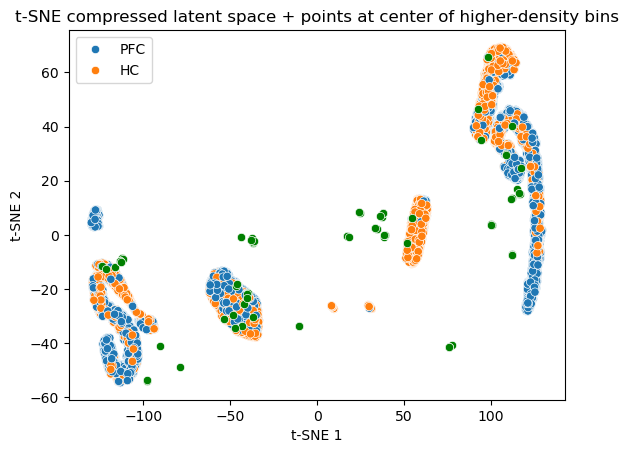

In [932]:
# cmap1 = cm.get_cmap('gist_heat')
# cmap2 = cm.get_cmap('Blues')
# custom_palette = [cmap1(0.5), cmap1(0.85), cmap2(0.4), cmap2(0.99)]
# bin_order = ['0.0', '1.0', '2.0', '3.0']

plt.figure()
sns.scatterplot(x='t-SNE 1', y='t-SNE 2', hue='region', data=df_tsne.iloc[:56651,:])
ax1 = sns.scatterplot(x='t-SNE 1', y='t-SNE 2', data=df_tsne.iloc[56651:56738,:], color='green') # higher-density bins (86)
# ax2 = sns.scatterplot(x='t-SNE 1', y='t-SNE 2', data=df_tsne.iloc[56738:56807,:], color='orange') # lower-density bins (68)
# sns.scatterplot(x='t-SNE 1', y='t-SNE 2', data=df_tsne.iloc[56807:,:], color='red') # empty bins (1048422)
plt.title('t-SNE compressed latent space + points at center of higher-density bins')

custom_handles = [
    # Line2D([0], [0], marker='o', color='w', markerfacecolor=custom_palette[0], markersize=6, label='bin 0'),
    # Line2D([0], [0], marker='o', color='w', markerfacecolor=custom_palette[1], markersize=6, label='bin 1'),
    # Line2D([0], [0], marker='o', color='w', markerfacecolor=custom_palette[2], markersize=6, label='bin 2'),
    # Line2D([0], [0], marker='o', color='w', markerfacecolor=custom_palette[3], markersize=6, label='bin 3'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=6, label='high-density bin'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=6, label='low-density bin'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='orange', markersize=6, label='low-density bin')
]

# ax1.legend(handles=custom_handles)

Text(0.5, 1.0, 't-SNE compressed latent space + points at center of nonempty bins')

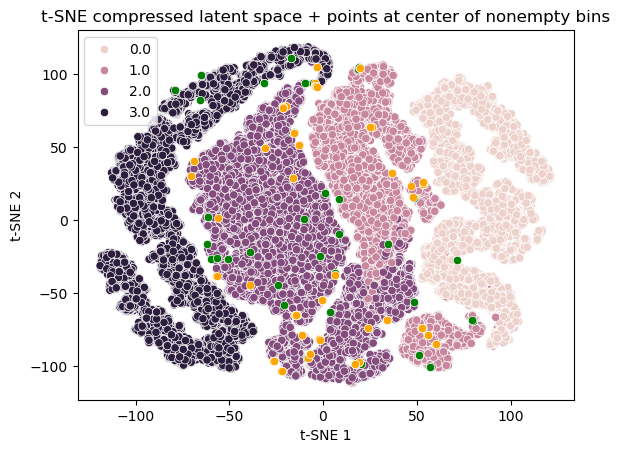

In [939]:
plt.figure()
sns.scatterplot(x='t-SNE 1', y='t-SNE 2', hue='label', data=df_tsne_nonempty.iloc[:56651,:])
ax1 = sns.scatterplot(x='t-SNE 1', y='t-SNE 2', data=df_tsne_nonempty.iloc[56651:56738,:], color='green') # higher-density bins (86)
ax2 = sns.scatterplot(x='t-SNE 1', y='t-SNE 2', data=df_tsne_nonempty.iloc[56738:,:], color='orange') # lower-density bins (68)
plt.title('t-SNE compressed latent space + points at center of nonempty bins')

## Try openTSNE: plot new points into existing embedding

In [1314]:
tsne = oTSNE(
    perplexity=30,
    metric="euclidean",
    n_jobs=8,
    random_state=22,
    verbose=True,
)

In [1315]:
embedding_latent_space = tsne.fit(latent_space)

--------------------------------------------------------------------------------
TSNE(early_exaggeration=12, n_jobs=8, random_state=22, verbose=True)
--------------------------------------------------------------------------------
===> Finding 90 nearest neighbors using Annoy approximate search using euclidean distance...
   --> Time elapsed: 2.70 seconds
===> Calculating affinity matrix...
   --> Time elapsed: 0.36 seconds
===> Calculating PCA-based initialization...
   --> Time elapsed: 0.00 seconds
===> Running optimization with exaggeration=12.00, lr=4720.83 for 250 iterations...
Iteration   50, KL divergence 5.2331, 50 iterations in 0.7149 sec
Iteration  100, KL divergence 4.6234, 50 iterations in 0.7359 sec
Iteration  150, KL divergence 4.3193, 50 iterations in 0.7342 sec
Iteration  200, KL divergence 4.1674, 50 iterations in 0.7466 sec
Iteration  250, KL divergence 4.0758, 50 iterations in 0.7224 sec
   --> Time elapsed: 3.65 seconds
===> Running optimization with exaggeration=1

In [1316]:
embedding_latent_space

TSNEEmbedding([[-41.28083376,  39.6032496 ],
               [-75.4919926 , -73.31284881],
               [  9.08856473, -42.50148599],
               ...,
               [  8.40103003, -12.41512611],
               [-64.37894851,  71.68339732],
               [-25.73155704,  10.47155475]], shape=(56650, 2))

In [1317]:
df_otsne = pd.DataFrame(embedding_latent_space, columns = ['t-SNE 1', 't-SNE 2'])
df_otsne['label'] = df_latent['label']
df_otsne['decoded_cfm'] = df_latent['decoded_cfm']
df_otsne['strain'] = df_latent2['Strain']
df_otsne['region'] = df_latent2['region']

In [1318]:
df_otsne

,t-SNE 1,t-SNE 2,label,decoded_cfm,strain,region
0,-41.280834,39.603250,2,1.048495,33,PFC
1,-75.491993,-73.312849,3,1.236806,124,PFC
2,9.088565,-42.501486,2,1.044764,33,HC
3,-49.935022,67.603311,3,-0.825561,B6,HC
4,67.344851,-85.507155,0,0.690024,65,HC
...,...,...,...,...,...,...
56645,-44.487827,90.822098,3,0.267969,53,PFC
56646,76.132638,81.997176,0,-0.972245,83,PFC
56647,8.401030,-12.415126,2,0.547159,113,HC
56648,-64.378949,71.683397,3,1.229240,124,HC


In [1331]:
embedding_nonempty = embedding_latent_space.transform(np.array(center_bin_coords))

===> Finding 15 nearest neighbors in existing embedding using Annoy approximate search...
   --> Time elapsed: 0.06 seconds
===> Calculating affinity matrix...
   --> Time elapsed: 0.00 seconds
===> Running optimization with exaggeration=4.00, lr=0.10 for 0 iterations...
   --> Time elapsed: 0.00 seconds
===> Running optimization with exaggeration=1.50, lr=0.10 for 250 iterations...
Iteration   50, KL divergence 20292.4414, 50 iterations in 1.1721 sec
Iteration  100, KL divergence 20177.0494, 50 iterations in 1.1682 sec
Iteration  150, KL divergence 20113.3800, 50 iterations in 1.2445 sec
Iteration  200, KL divergence 20068.4658, 50 iterations in 1.2207 sec
Iteration  250, KL divergence 20036.7100, 50 iterations in 1.1750 sec
   --> Time elapsed: 5.98 seconds


In [1297]:
embedding_empty = embedding_latent_space.transform(np.array(center_bin_coords_empty))

===> Finding 15 nearest neighbors in existing embedding using Annoy approximate search...
   --> Time elapsed: 25.16 seconds
===> Calculating affinity matrix...
   --> Time elapsed: 0.61 seconds
===> Running optimization with exaggeration=4.00, lr=0.10 for 0 iterations...
   --> Time elapsed: 0.00 seconds
===> Running optimization with exaggeration=1.50, lr=0.10 for 250 iterations...
Iteration   50, KL divergence 19132867.6357, 50 iterations in 7.5643 sec
Iteration  100, KL divergence 19104073.5752, 50 iterations in 7.5051 sec
Iteration  150, KL divergence 19088087.4729, 50 iterations in 7.3995 sec
Iteration  200, KL divergence 19077506.1884, 50 iterations in 7.4779 sec
Iteration  250, KL divergence 19069737.8614, 50 iterations in 7.4217 sec
   --> Time elapsed: 37.37 seconds


In [1332]:
df_otsne_nonempty = pd.DataFrame(embedding_nonempty, columns = ['t-SNE 1', 't-SNE 2'])

In [1299]:
df_bin3 = df_latent.copy()
df_bin3 = df_bin3[df_bin3['label'] == 3]
unique_bin3_bins = df_bin3['density_bin'].apply(tuple).unique()
unique_bin3_bins

array([(4, 3, 3, 3, 3, 2, 2, 3, 2, 2), (10, 10, 8, 8, 8, 7, 6, 7, 5, 5),
       (8, 8, 7, 6, 7, 6, 5, 6, 5, 5), ...,
       (13, 13, 11, 10, 10, 9, 7, 9, 7, 7),
       (14, 14, 12, 12, 12, 11, 9, 10, 8, 8),
       (14, 14, 11, 11, 11, 10, 8, 9, 8, 7)], shape=(1358,), dtype=object)

In [1300]:
df_density_bin3 = df_density[df_density['nonzero_bins'].isin(unique_bin3_bins)]
df_density_bin3

,nonzero_bins,counts,density
2,"(9, 9, 7, 7, 7, 6, 5, 6, 5, 5)",409,0.007220
4,"(8, 8, 6, 6, 6, 5, 4, 5, 4, 4)",366,0.006461
8,"(5, 5, 4, 4, 4, 3, 3, 4, 3, 3)",288,0.005084
10,"(4, 4, 3, 3, 3, 2, 2, 3, 2, 2)",272,0.004801
12,"(6, 6, 5, 5, 5, 4, 3, 4, 3, 3)",256,0.004519
...,...,...,...
19222,"(16, 16, 13, 13, 13, 11, 10, 10, 8, 8)",1,0.000018
19227,"(6, 6, 5, 5, 4, 3, 3, 4, 3, 3)",1,0.000018
19269,"(13, 13, 11, 10, 10, 9, 7, 9, 7, 7)",1,0.000018
19289,"(14, 14, 12, 12, 12, 11, 9, 10, 8, 8)",1,0.000018


In [1301]:
df_bin0 = df_latent.copy()
df_bin0 = df_bin0[df_bin0['label'] == 0]
unique_bin0_bins = df_bin0['density_bin'].apply(tuple).unique()
unique_bin0_bins

array([(43, 43, 44, 44, 46, 45, 46, 46, 46, 46),
       (47, 47, 48, 48, 49, 48, 49, 49, 49, 49),
       (45, 45, 46, 46, 47, 47, 47, 47, 47, 47),
       (41, 41, 43, 43, 44, 44, 45, 45, 45, 45),
       (47, 47, 48, 48, 49, 49, 49, 49, 49, 49),
       (41, 41, 43, 44, 45, 45, 46, 46, 46, 46),
       (44, 44, 45, 46, 47, 46, 47, 47, 47, 47),
       (46, 46, 47, 47, 48, 47, 48, 48, 48, 48),
       (48, 48, 49, 49, 50, 49, 50, 50, 49, 49),
       (45, 45, 46, 46, 48, 47, 47, 48, 48, 48),
       (46, 46, 47, 47, 48, 48, 48, 48, 48, 48),
       (44, 44, 45, 45, 46, 46, 46, 46, 47, 47),
       (45, 45, 46, 46, 47, 47, 48, 48, 48, 48),
       (50, 50, 51, 51, 52, 51, 52, 52, 52, 51),
       (44, 44, 46, 46, 47, 46, 47, 47, 47, 47),
       (48, 48, 49, 48, 50, 49, 49, 49, 49, 49),
       (41, 41, 43, 43, 45, 44, 45, 45, 46, 45),
       (43, 43, 45, 45, 46, 46, 46, 47, 47, 47),
       (44, 44, 46, 46, 48, 47, 47, 48, 48, 48),
       (47, 48, 48, 48, 49, 49, 49, 49, 49, 49),
       (51, 51, 51, 

In [1302]:
df_density_bin0 = df_density[df_density['nonzero_bins'].isin(unique_bin0_bins)]
df_density_bin0

,nonzero_bins,counts,density
0,"(46, 46, 47, 47, 48, 48, 48, 48, 48, 48)",503,0.008879
1,"(46, 46, 47, 47, 48, 47, 48, 48, 48, 48)",411,0.007255
3,"(47, 47, 48, 48, 49, 48, 49, 49, 49, 49)",377,0.006655
5,"(44, 44, 46, 46, 47, 46, 47, 47, 47, 47)",336,0.005931
6,"(45, 45, 46, 46, 47, 47, 47, 47, 47, 47)",315,0.005560
...,...,...,...
19092,"(50, 51, 51, 50, 50, 50, 50, 50, 49, 49)",1,0.000018
19102,"(41, 41, 43, 44, 44, 44, 45, 45, 45, 46)",1,0.000018
19132,"(42, 42, 44, 45, 45, 45, 46, 46, 46, 46)",1,0.000018
19220,"(49, 49, 50, 50, 50, 50, 50, 51, 50, 50)",1,0.000018


In [1333]:
df_otsne_nonempty

,t-SNE 1,t-SNE 2
0,73.813580,-15.628590
1,-79.015959,28.899253
2,81.031546,-27.447986
3,95.581723,43.926607
4,-88.300681,-40.506231
...,...,...
1769,-23.021539,95.782815
1770,-40.588423,39.803249
1771,-48.780209,-33.828226
1772,60.011417,21.818922


In [1304]:
df_otsne_empty = pd.DataFrame(embedding_empty, columns = ['t-SNE 1', 't-SNE 2'])
df_otsne_empty

,t-SNE 1,t-SNE 2
0,-37.738514,80.777449
1,-21.727523,71.445229
2,-59.155513,36.953640
3,-34.888645,81.909721
4,-21.082125,71.797825
...,...,...
1048417,63.179943,-39.642911
1048418,50.245875,-82.883342
1048419,64.715420,-22.817442
1048420,63.146263,-39.693906


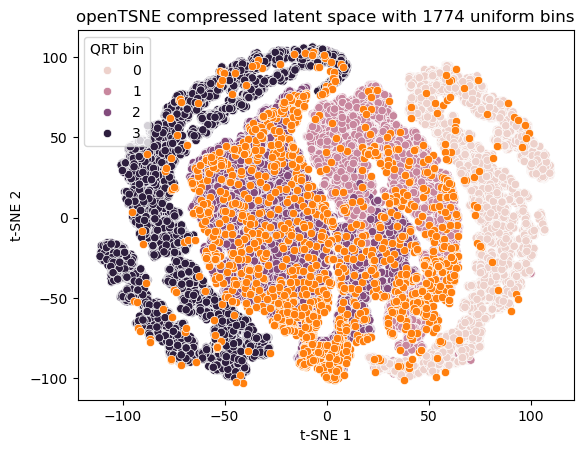

In [1336]:
plt.figure()
sns.scatterplot(x='t-SNE 1', y='t-SNE 2', hue='label', data=df_otsne)
sns.scatterplot(x='t-SNE 1', y='t-SNE 2', data=df_otsne_nonempty)
# ax1 = sns.scatterplot(x='t-SNE 1', y='t-SNE 2', data=df_tsne_nonempty.iloc[56651:56738,:], color='green') # higher-density bins (86)
# ax2 = sns.scatterplot(x='t-SNE 1', y='t-SNE 2', data=df_tsne_nonempty.iloc[56738:,:], color='orange') # lower-density bins (68)
plt.title('openTSNE compressed latent space with 1774 uniform bins')
plt.legend(title = 'QRT bin')

Text(0.5, 1.0, 'openTSNE compressed latent space')

/home/nghayes/miniforge3/envs/c-gmvae/lib/python3.14/site-packages/IPython/core/events.py:100: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/home/nghayes/miniforge3/envs/c-gmvae/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


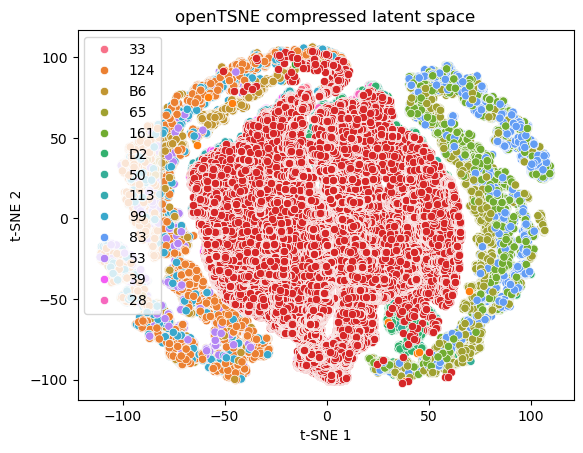

In [ ]:
# ORIGINAL VERSION
plt.figure()
sns.scatterplot(x='t-SNE 1', y='t-SNE 2', hue='label', data=df_otsne)
sns.scatterplot(x='t-SNE 1', y='t-SNE 2', data=df_otsne_nonempty.iloc[:87,:])
sns.scatterplot(x='t-SNE 1', y='t-SNE 2', data=df_otsne_nonempty.iloc[87:,:])
sns.scatterplot(x='t-SNE 1', y='t-SNE 2', data=df_otsne_empty)
# ax1 = sns.scatterplot(x='t-SNE 1', y='t-SNE 2', data=df_tsne_nonempty.iloc[56651:56738,:], color='green') # higher-density bins (86)
# ax2 = sns.scatterplot(x='t-SNE 1', y='t-SNE 2', data=df_tsne_nonempty.iloc[56738:,:], color='orange') # lower-density bins (68)
plt.title('openTSNE compressed latent space')

In [1306]:
# FIND LABELS FOR THE NEW POINTS - HOW????
# EVENTUALLY WANT TO DO BELOW:
# nonempty_bin_generated_cfm = decode_cfm_along_trajectory(model, center_bin_coords, center_bin_labels, device=device)

/tmp/ipykernel_52262/4170169750.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap3 = cm.get_cmap('viridis')


<Axes: xlabel='t-SNE 1', ylabel='t-SNE 2'>

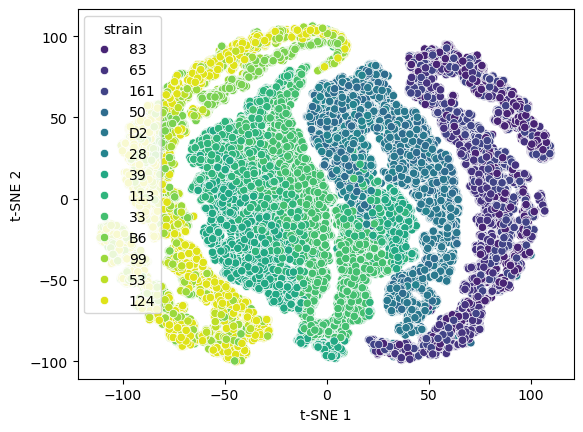

In [1307]:
# WHAT IS THIS MESS????
# FIXED! Was pulling strain info from df_gene, which has different ordering of points

strain_order = ['83', '65', '161', '50', 'D2', '28', '39', '113', '33', 'B6', '99', '53',
 '124']

cmap3 = cm.get_cmap('viridis')
custom_palette = [cmap3(0.1), cmap3(0.15), cmap3(0.2), cmap3(0.35), cmap3(0.4), cmap3(0.45), cmap3(0.6), cmap3(0.65), cmap3(0.7), cmap3(0.8), cmap3(0.85), cmap3(0.9), cmap3(0.95)]
temp = df_otsne.copy()
temp["strain"] = temp["strain"].astype(str)

sns.scatterplot(x='t-SNE 1', y='t-SNE 2', hue="strain",hue_order = strain_order, palette=custom_palette, data=df_otsne)

In [1308]:
def get_point_bin(point, lower_limits, upper_limits, num_bins_per_dim):
    '''
    Function to get the data density bin of a point
    NOTE: this assumes we're setting a desired # of bins per latent dimension
    Alternatively, could define a bin size, in which case implementation would be slightly different

    Args:
        point: coordinate in latent space (shape: [latent_dim,] or [latent_dim,1])
        lower_limits: list of lower bounds of all latent variables (len: latent_dim)
        upper_limits: list of upper bounds of all latent variables (len: latent_dim)
        num_bins_per_dim: # of data density bins per latent dimension

    Returns:
        this_point_bin: list of len: latent_dim containing data density bin indices of this point

    '''

    latent_dim = len(lower_limits)
    this_point_bin = []

    for dim in range(latent_dim):
        dist_from_lower_limit = point[dim] - lower_limits[dim]
        bin_size_dim = (upper_limits[dim] - lower_limits[dim])/num_bins_per_dim
        bin_index = math.floor(dist_from_lower_limit/bin_size_dim)
        this_point_bin.append(bin_index)
    
    return this_point_bin

## Attempt myopic density-guided trajectories

In [427]:
# Loading pairs of start, end points
# from Generate_Latent_Trajectories.ipynb on Great Lakes

with open('/home/nghayes/latent-space-trajectories/pairs.pkl', 'rb') as file:
    pairs = pickle.load(file)

In [884]:
kde_dict[(3,3,3,3,3,3,3,3,3,3)]((-8.4,-4.2,2.88,9.409,14.132,19.746,26.679,30.815,39.042,44.011))

array([2787.52796143])

In [965]:
lower_int_limits = []
for i in range(len(upper_limits)):
    lower_int_limits.append(upper_limits[i]-bin_sizes[i])
lower_int_limits

[-12.5, -8.25, -2.5, 3.25, 7.25, 12.75, 18.5, 22.5, 29.5, 34.25]

In [963]:
kde_dict[(3,3,3,3,3,3,3,3,3,3)].integrate_box(lower_int_limits, upper_limits)

np.float64(0.8878438259322383)

In [960]:
bin_sizes = []
for i in range(len(upper_limits)):
    bin_sizes.append((upper_limits[i] - lower_limits[i])/num_bins_per_dim)

bin_sizes

[7.5, 7.25, 8.5, 9.75, 9.75, 10.25, 11.5, 11.5, 13.5, 13.75]

In [962]:
lower_int_limits = []
for i in range(len(upper_limits)):
    lower_int_limits.append(upper_limits[i]-bin_sizes[i])
lower_int_limits

[-12.5, -8.25, -2.5, 3.25, 7.25, 12.75, 18.5, 22.5, 29.5, 34.25]

In [949]:
upper_limits

[-5, -1, 6, 13, 17, 23, 30, 34, 43, 48]

In [1132]:
def kde_list_sum(z_point, kde_list, kde_weights):
    kde_sum = 0
    for i in range(len(kde_list)):
        this_kde = kde_list[i](z_point)[0]
        print(this_kde)
        kde_sum += kde_weights[i]*this_kde
    
    return kde_sum

In [1137]:
kde_list_sum(latent_space[4], kde_qrt_bins, kde_qrt_weights)

418908.8636691535
0.25249749462060384
0.0
0.0


np.float64(84550.87090065193)

In [1156]:
df_latent.loc[:20,:]

,z_1,z_2,z_3,z_4,z_5,z_6,z_7,z_8,z_9,z_10,label,decoded_cfm,density_bin
0,-24.256855,-18.943563,-19.148005,-13.069660,-7.281853,-6.647669,-1.973320,1.312754,5.479063,10.920240,2,1.048495,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]"
1,-32.498856,-27.973068,-25.985146,-23.571732,-19.487030,-15.888780,-14.033054,-9.226448,-8.665678,-4.734122,3,1.236806,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"
2,-17.562922,-16.157148,-7.969545,-5.897250,1.853780,4.455924,9.762284,14.726957,23.734491,29.096786,2,1.044764,"[2, 1, 2, 2, 2, 2, 2, 2, 2, 2]"
3,-28.858011,-24.174309,-22.691444,-19.941648,-16.066748,-12.556651,-10.494271,-5.782712,-5.136093,-1.035175,3,-0.825561,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"
4,-10.571421,-6.463661,0.640753,7.082870,11.920109,17.315226,24.198599,28.219280,36.607440,41.267610,0,0.690024,"[3, 3, 3, 3, 3, 3, 3, 3, 3, 3]"
5,-8.174380,-4.043670,2.960599,9.497574,14.260602,19.690483,26.765537,30.756020,39.044262,43.966454,0,-1.581379,"[3, 3, 3, 3, 3, 3, 3, 3, 3, 3]"
6,-12.695596,-7.713936,-4.878980,-1.440421,6.012704,8.817274,13.797771,18.695784,27.195430,32.340393,1,-1.313093,"[2, 3, 2, 2, 2, 2, 2, 2, 2, 2]"
7,-16.000040,-10.902713,-6.684124,-3.191145,4.525127,6.925598,12.219912,16.805430,25.249464,30.431843,1,-1.063343,"[2, 2, 2, 2, 2, 2, 2, 2, 2, 2]"
8,-29.944551,-25.133204,-23.212881,-20.931145,-16.555386,-13.060875,-11.124614,-6.219855,-5.710696,-1.613443,3,1.231194,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"
9,-24.174894,-18.247770,-17.225182,-11.089184,-5.395521,-4.119117,0.220880,4.212738,8.117303,13.438895,2,0.547863,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]"


In [1191]:
# trying to find closest point

point_test = latent_space[1] + .00001

print(latent_space - point_test)

distances_to_points = np.linalg.norm(latent_space - point_test, axis=1)

print(distances_to_points)

print(np.min(distances_to_points))

print(np.argmin(distances_to_points))

[[ 8.24198914e+00  9.02949524e+00  6.83713150e+00 ...  1.05391932e+01
   1.41447315e+01  1.56543522e+01]
 [-1.14440918e-05 -9.53674316e-06 -9.53674316e-06 ... -9.53674316e-06
  -9.53674316e-06 -1.00135803e-05]
 [ 1.49359226e+01  1.18159103e+01  1.80155907e+01 ...  2.39533958e+01
   3.24001617e+01  3.38308983e+01]
 ...
 [ 1.53792801e+01  1.42676115e+01  1.87890263e+01 ...  2.49777412e+01
   3.30648956e+01  3.43716698e+01]
 [ 3.22790909e+00  3.44132233e+00  3.37342453e+00 ...  3.38083744e+00
   3.40602207e+00  3.40204430e+00]
 [ 8.47709656e+00  9.61161995e+00  9.38890266e+00 ...  1.23343039e+01
   1.56937981e+01  1.72083855e+01]]
[3.52492485e+01 3.09650568e-05 7.21336670e+01 ... 7.52250443e+01
 1.06378355e+01 3.98311882e+01]
3.0965057e-05
1


In [1193]:
# Density-guided trajectory: just go in direction of log-density gradient
# USING 4 KDES FIT TO QRT BIN DATA

# start = pairs[1][0]
# start_coordinate = start['z']
# start_label = start['label']
# start_index = start['index']
# start_cfm = start['cfm']

start_coordinate = latent_space[7]
start_bin = get_point_bin(start_coordinate, lower_limits, upper_limits, num_bins_per_dim)

print(start_coordinate)
print(start_bin)
# print(start_index)

print('kde at start point = ', kde_list_sum(start_coordinate, kde_qrt_bins, kde_qrt_weights))

path = [start_coordinate]
current_point = start_coordinate.copy()

radius = 0.4
bin_check_radius = radius
neighbor_lower_bound = 20
step_size = 2*radius

for i in range(50):
    current_point_bin = get_point_bin(current_point, lower_limits, upper_limits, num_bins_per_dim)
    
    print('bin of current point =', current_point_bin)
    kde_current_point = kde_list_sum(current_point, kde_qrt_bins, kde_qrt_weights)
    print('kde at current point =', kde_current_point)

    density_grad = gradient_multiple_kdes(current_point, kde_qrt_bins, kde_qrt_weights)
    grad_norm = np.linalg.norm(density_grad)
    if grad_norm > 0:
        density_grad /= grad_norm

    print('gradient of log density =', density_grad)
    # maybe add condition for if gradient = 0
    # randomly go in some direction
    # OR go to nearest point?

    if np.max(density_grad)>0:
        proposed_next_point = current_point + density_grad * step_size
    
    else:
        # this didn't work
        # still kept getting gradient = 0
        # this is not smart because I know space is sparse, I'm likely to end up somewhere kde = 0
        
        # print('moving in random direction')
        # random_perturb = np.random.randn(latent_dim)
        # random_unit = random_perturb / np.linalg.norm(random_perturb)
        # print(random_unit)
        # proposed_next_point = current_point + random_unit * step_size

        # try going toward nearest point (could also go TO nearest point)

        print('moving toward closest point')
        distances_to_points = np.linalg.norm(latent_space - current_point, axis=1)
        closest_point_index = np.argmin(distances_to_points)
        closest_point = latent_space[closest_point_index]

        closest_point_dir = closest_point - current_point
        closest_point_norm = np.linalg.norm(closest_point_dir)
        
        if closest_point_norm > 0:
            closest_point_dir /= closest_point_norm
        
        print(closest_point_dir)
        
        proposed_next_point = current_point + closest_point_dir * step_size

    
    print('proposed next point =', proposed_next_point, '\n')

    path.append(proposed_next_point)

    current_point = proposed_next_point

[-16.00004   -10.902713   -6.6841235  -3.1911447   4.5251274   6.9255977
  12.219912   16.80543    25.249464   30.431843 ]
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
0.0
52.92958890512802
9.148529403274881e-07
0.0
kde at start point =  10.69149698560456
bin of current point = [2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
0.0
52.92958890512802
9.148529403274881e-07
0.0
kde at current point = 10.69149698560456
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[-2.5221257   1.6891075   0.7804841   2.363378   -1.1559367   5.471635
 -7.7981253  -0.45397127 -1.3546174   3.7344656 ]
[ -6.04794     -6.222596    -0.10425086  22.32849    -38.206013
  56.215214   -31.474997   -16.711851   -36.946346    51.009827  ]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
gradient of log density = [-0.06978842 -0.04906465  0.00317047  0.2207736  -0.362434    0.5532897
 -0.3349181  -0.1582596  -0.35174125  0.49552515]
proposed next point = [-16.05587   -10.941964   -6.681587   -3.014526    4.2351804   7.3682294
  11.951977   16.678822   24.968071   30.828262 ] 

bin 

In [1166]:
np.max(density_grad)>0

np.False_

In [1125]:
# Density-guided trajectory: just go in direction of log-density gradient
# USING KDES FIT TO DATA DENSITY BINS

start = pairs[1][0]
start_coordinate = start['z']
start_label = start['label']
start_index = start['index']
start_cfm = start['cfm']
start_bin = get_point_bin(start_coordinate, lower_limits, upper_limits, num_bins_per_dim)

print(start_coordinate)
print(start_bin)
print(start_index)

kde_start_point = kde_dict[tuple(start_bin)]
print(kde_start_point(start_coordinate)[0])

path = [start_coordinate]
current_point = start_coordinate.copy()

radius = 0.2
bin_check_radius = radius
neighbor_lower_bound = 20
step_size = 2*radius

for i in range(20):
    current_point_bin = get_point_bin(current_point, lower_limits, upper_limits, num_bins_per_dim)

    if tuple(current_point_bin) in kde_dict:
        print('~~~~~nonempty bin found!~~~~~')
    if tuple(current_point_bin) not in kde_dict:
        print('~~~~~this bin is empty :(~~~~~')
    
    print('bin of current point =', current_point_bin)
    kde_current_point = kde_dict[tuple(current_point_bin)]
    print('kde at current point =', kde_current_point(current_point)[0])

    density_grad = numerical_log_density_gradient(current_point, kde_current_point)
    grad_norm = np.linalg.norm(density_grad)
    if grad_norm > 0:
        density_grad /= grad_norm

    print('gradient of log density =', density_grad)
    proposed_next_point = current_point + density_grad * step_size
    print('proposed next point =', proposed_next_point, '\n')

    path.append(proposed_next_point)

    current_point = proposed_next_point

[-8.407204  -4.2466807  2.881962   9.409945  14.161424  19.746548
 26.679409  30.815266  39.04207   44.011818 ]
[3, 3, 3, 3, 3, 3, 3, 3, 3, 3]
18260
4154.71420980994
~~~~~nonempty bin found!~~~~~
bin of current point = [3, 3, 3, 3, 3, 3, 3, 3, 3, 3]
kde at current point = 4154.71420980994
gradient of log density = [-0.5792072   0.5609589   0.21926533  0.03357932  0.04181645 -0.47814348
  0.17237659  0.04643096  0.12747428 -0.14882943]
proposed next point = [-8.638886  -4.0222974  2.9696681  9.423376  14.17815   19.55529
 26.74836   30.833838  39.09306   43.952286 ] 

~~~~~nonempty bin found!~~~~~
bin of current point = [3, 3, 3, 3, 3, 3, 3, 3, 3, 3]
kde at current point = 1.3672834503853155e-16
gradient of log density = [ 0.41203085 -0.5139026   0.08443544 -0.16670561  0.08002567  0.5964251
 -0.35807455 -0.19612062  0.0415321   0.02611602]
proposed next point = [-8.474074  -4.2278585  3.0034423  9.356694  14.21016   19.79386
 26.60513   30.75539   39.109673  43.96273  ] 

~~~~~nonempty

In [886]:
print(kde_dict[tuple(start_bin)](start_coordinate)[0])
print(kde_dict[tuple(start_bin)](start_coordinate + [0.1,0,0,0,0,0,0,0,0,0])[0])
print(kde_dict[tuple(start_bin)](start_coordinate + [0.1,0.1,0,0,0,0,0,0,0,0])[0])

4154.71420980994
35.64838049080152
3341.859870379309


### CHECKS: Try KDEs added together in 2D, 3D

In [223]:
# first need to make 2D, 3D data
# only select first two latent variables
# also only need first two density bins

df_latent_2D = df_latent[['z_1', 'z_2', 'label', 'decoded_cfm']]
df_latent_2D['density_bin'] = [bin[:2] for bin in df_latent['density_bin']]
df_latent_2D.head(20)

,z_1,z_2,label,decoded_cfm,density_bin
0,-24.256855,-18.943563,2,1.048495,"[1, 1]"
1,-32.498856,-27.973068,3,1.236806,"[0, 0]"
2,-17.562922,-16.157148,2,1.044764,"[2, 1]"
3,-28.858011,-24.174309,3,-0.825561,"[0, 0]"
4,-10.571421,-6.463661,0,0.690024,"[3, 3]"
5,-8.174380,-4.043670,0,-1.581379,"[3, 3]"
6,-12.695596,-7.713936,1,-1.313093,"[2, 3]"
7,-16.000040,-10.902713,1,-1.063343,"[2, 2]"
8,-29.944551,-25.133204,3,1.231194,"[0, 0]"
9,-24.174894,-18.247770,2,0.547863,"[1, 1]"


In [201]:
df_density_2D = df_latent_2D['density_bin'].apply(tuple).value_counts().rename_axis('nonzero_bins').reset_index(name='counts')
df_density_2D['density'] = df_density_2D['counts']/len(latent_space)
df_density_2D

,nonzero_bins,counts,density
0,"(3, 3)",13302,0.234810
1,"(0, 0)",13047,0.230309
2,"(2, 2)",12299,0.217105
3,"(1, 1)",11885,0.209797
4,"(1, 2)",2648,0.046743
5,"(2, 1)",1749,0.030874
6,"(0, 2)",740,0.013063
7,"(2, 3)",424,0.007485
8,"(0, 1)",338,0.005966
9,"(1, 0)",179,0.003160


In [343]:
latent_space_2D = df_latent_2D[[f'z_{j+1}' for j in range(2)]].values.astype('float32')

kde_list_2D = []
kde_dict_2D = {}
for row in df_density_2D.itertuples():
    bin_point_indices = [] # pull indices of points in this bin, select those rows from latent_space_2D
    bin = row.nonzero_bins
    print('this bin =', bin)
    for point in df_latent_2D.itertuples():
        if tuple(point.density_bin) == bin:
            bin_point_indices.append(point.Index)
    print(len(bin_point_indices), bin_point_indices)

    latent_space_bin = latent_space_2D[bin_point_indices]
    kde_bin = gaussian_kde(latent_space_bin.T)

    kde_list_2D.append(kde_bin)
    kde_dict_2D[bin] = kde_bin

    

latent_space_2D

this bin = (3, 3)
13302 [4, 5, 10, 14, 26, 27, 35, 37, 41, 42, 45, 53, 56, 57, 60, 66, 67, 68, 74, 89, 90, 91, 99, 100, 106, 112, 133, 136, 145, 148, 150, 158, 166, 174, 175, 178, 180, 183, 185, 191, 193, 194, 195, 202, 203, 218, 224, 231, 235, 238, 242, 243, 251, 253, 257, 262, 265, 271, 277, 278, 279, 281, 295, 298, 302, 305, 310, 315, 340, 342, 343, 350, 356, 361, 364, 367, 377, 381, 383, 388, 397, 403, 404, 405, 406, 408, 429, 432, 433, 434, 436, 443, 447, 448, 449, 451, 453, 456, 458, 459, 465, 467, 469, 476, 484, 491, 496, 502, 507, 508, 511, 517, 521, 524, 532, 534, 535, 536, 549, 555, 556, 557, 558, 559, 561, 562, 564, 566, 569, 575, 576, 581, 582, 590, 598, 602, 605, 606, 614, 617, 619, 630, 636, 639, 648, 655, 668, 673, 676, 681, 682, 686, 688, 693, 699, 700, 702, 705, 706, 709, 713, 717, 718, 720, 725, 726, 731, 734, 736, 738, 739, 742, 743, 746, 749, 753, 760, 762, 763, 764, 767, 768, 770, 782, 788, 789, 794, 801, 803, 811, 813, 814, 816, 819, 824, 827, 828, 830, 833, 836, 

array([[-24.256855, -18.943563],
       [-32.498856, -27.973068],
       [-17.562922, -16.157148],
       ...,
       [-17.119564, -13.705447],
       [-29.270935, -24.531736],
       [-24.021748, -18.361439]], shape=(56650, 2), dtype=float32)

In [237]:
# testing how to select indices in numpy array
array_indices = [0, 3, 4, 10, 15]

latent_space_bin = latent_space_2D[array_indices]
latent_space_bin

array([[-24.256855 , -18.943563 ],
       [-28.858011 , -24.174309 ],
       [-10.571421 ,  -6.463661 ],
       [-11.992315 ,  -7.9590416],
       [-31.730787 , -26.974228 ]], dtype=float32)

In [339]:
kde_dict_2D

{(3, 3): <scipy.stats._kde.gaussian_kde at 0x7b11d9712690>,
 (0, 0): <scipy.stats._kde.gaussian_kde at 0x7b11d97125d0>,
 (2, 2): <scipy.stats._kde.gaussian_kde at 0x7b11d9711d90>,
 (1, 1): <scipy.stats._kde.gaussian_kde at 0x7b11d9712810>,
 (1, 2): <scipy.stats._kde.gaussian_kde at 0x7b11d97128d0>,
 (2, 1): <scipy.stats._kde.gaussian_kde at 0x7b11d9712990>,
 (0, 2): <scipy.stats._kde.gaussian_kde at 0x7b11d9712a50>,
 (2, 3): <scipy.stats._kde.gaussian_kde at 0x7b11d9712b10>,
 (0, 1): <scipy.stats._kde.gaussian_kde at 0x7b11d9712bd0>,
 (1, 0): <scipy.stats._kde.gaussian_kde at 0x7b11d9712c90>,
 (3, 2): <scipy.stats._kde.gaussian_kde at 0x7b11d9712d50>}

In [277]:
# test: evaluate various individual bin KDEs at different points
# look at which bin the test point is in - try KDE for that bin AND KDE NOT for that bin evaluated at that point
# KDE for different bin should give ~ 0, KDE for that bin should be nonzero probably
# that does seem to be working

test_point = latent_space_2D[1]
test_point.reshape(-1, 1) # ensure correct shape for KDE
kde_list_2D[0](test_point)

array([0.])

In [293]:
kde_list_2D[0]

In [161]:
df_latent_3D = df_latent[['z_1', 'z_2', 'z_3', 'label', 'decoded_cfm']]
df_latent_3D['density_bin'] = [bin[:3] for bin in df_latent['density_bin']]
df_latent_3D

,z_1,z_2,z_3,label,decoded_cfm,density_bin
0,-24.256855,-18.943563,-19.148005,2,1.048495,"[1, 1, 1]"
1,-32.498856,-27.973068,-25.985146,3,1.236806,"[0, 0, 0]"
2,-17.562922,-16.157148,-7.969545,2,1.044764,"[2, 1, 2]"
3,-28.858011,-24.174309,-22.691444,3,-0.825561,"[0, 0, 0]"
4,-10.571421,-6.463661,0.640753,0,0.690024,"[3, 3, 3]"
...,...,...,...,...,...,...
56645,-28.579952,-23.901604,-22.118683,3,0.267969,"[0, 0, 0]"
56646,-7.582398,-3.366018,3.963249,0,-0.972245,"[3, 3, 3]"
56647,-17.119564,-13.705447,-7.196110,2,0.547159,"[2, 2, 2]"
56648,-29.270935,-24.531736,-22.611712,3,1.229240,"[0, 0, 0]"


In [199]:
df_density_3D = df_latent_3D['density_bin'].apply(tuple).value_counts().rename_axis('nonzero_bins').reset_index(name='counts')
df_density_3D['density'] = df_density_3D['counts']/len(latent_space)
df_density_3D

,nonzero_bins,counts,density
0,"(0, 0, 0)",13047,0.230309
1,"(3, 3, 3)",12140,0.214298
2,"(2, 2, 2)",10928,0.192904
3,"(1, 1, 1)",10306,0.181924
4,"(1, 2, 1)",2196,0.038764
5,"(1, 1, 0)",1542,0.027220
6,"(2, 1, 2)",1470,0.025949
7,"(2, 2, 3)",1309,0.023107
8,"(3, 3, 2)",1162,0.020512
9,"(0, 2, 0)",701,0.012374


In [278]:
latent_space_3D = df_latent_3D[[f'z_{j+1}' for j in range(3)]].values.astype('float32')

kde_list_3D = []
for row in df_density_3D.itertuples():
    bin_point_indices = [] # pull indices of points in this bin, select those rows from latent_space_2D
    bin = row.nonzero_bins
    print('this bin =', bin)
    for point in df_latent_3D.itertuples():
        if tuple(point.density_bin) == bin:
            bin_point_indices.append(point.Index)
    print(len(bin_point_indices), bin_point_indices)

    latent_space_bin = latent_space_3D[bin_point_indices]
    kde_bin = gaussian_kde(latent_space_bin.T)

    kde_list_3D.append(kde_bin)

    

latent_space_3D

this bin = (0, 0, 0)
13047 [1, 3, 8, 12, 13, 15, 16, 18, 25, 31, 39, 43, 44, 46, 47, 48, 50, 61, 62, 64, 71, 73, 78, 80, 82, 83, 92, 96, 98, 101, 102, 103, 107, 108, 113, 118, 119, 120, 121, 123, 125, 127, 132, 134, 142, 146, 152, 153, 154, 159, 163, 164, 169, 171, 172, 176, 177, 181, 189, 200, 201, 207, 217, 220, 222, 223, 228, 233, 236, 245, 249, 252, 259, 261, 268, 269, 275, 282, 283, 285, 287, 288, 290, 292, 301, 303, 304, 306, 309, 312, 313, 317, 319, 323, 324, 325, 329, 331, 333, 339, 341, 344, 346, 347, 351, 355, 365, 368, 369, 370, 373, 374, 380, 384, 391, 407, 413, 415, 417, 422, 423, 428, 431, 435, 437, 438, 441, 460, 461, 462, 463, 468, 472, 473, 474, 479, 480, 481, 493, 504, 506, 513, 514, 515, 516, 525, 540, 542, 545, 548, 551, 552, 570, 572, 573, 578, 580, 587, 592, 594, 595, 599, 611, 620, 633, 640, 643, 644, 646, 647, 658, 659, 669, 670, 675, 678, 684, 690, 696, 701, 703, 704, 710, 714, 721, 727, 730, 732, 737, 741, 744, 745, 751, 761, 766, 773, 774, 776, 777, 787, 790,

array([[-24.256855 , -18.943563 , -19.148005 ],
       [-32.498856 , -27.973068 , -25.985146 ],
       [-17.562922 , -16.157148 ,  -7.969545 ],
       ...,
       [-17.119564 , -13.705447 ,  -7.1961102],
       [-29.270935 , -24.531736 , -22.611712 ],
       [-24.021748 , -18.361439 , -16.596233 ]],
      shape=(56650, 3), dtype=float32)

In [356]:
test_point = latent_space_3D[1]
test_point.reshape(-1,1)
kde_list_3D[0](test_point)

array([0.50478648])

In [325]:
kde_list_3D[-1](latent_space_bin[5])

array([4.687594])

In [334]:
kde_list_3D[-1](latent_space_bin.T)

array([5.59026662, 7.43898865, 4.48666152, 4.21296365, 7.57294438,
       4.687594  ])

In [333]:
# def measure(n):
#     "Measurement model, return two coupled measurements."
#     m1 = np.random.normal(size=n)
#     m2 = np.random.normal(scale=0.5, size=n)
#     return m1+m2, m1-m2
# m1, m2 = measure(2000)
# xmin = m1.min()
# xmax = m1.max()
# ymin = m2.min()
# ymax = m2.max()
# X, Y = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]
# positions = np.vstack([X.ravel(), Y.ravel()])

# positions # shape: (2, 10000), 10000 points of dim 2

/tmp/ipykernel_52262/3515215404.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap1 = cm.get_cmap('gist_heat')
/tmp/ipykernel_52262/3515215404.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap2 = cm.get_cmap('Blues')


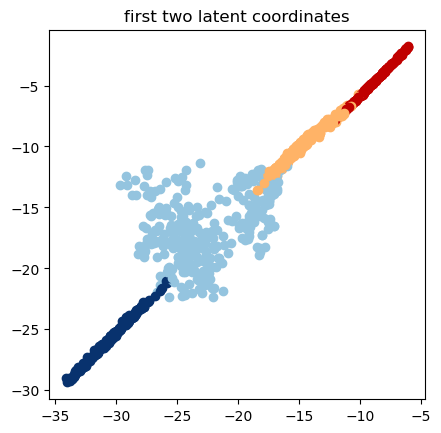

In [628]:
# plotting for some reason
dim_test = 2

cmap1 = cm.get_cmap('gist_heat')
cmap2 = cm.get_cmap('Blues')
custom_palette = [cmap1(0.5), cmap1(0.85), cmap2(0.4), cmap2(0.99)]

if dim_test == 2:
    iter_count = 0 # it takes FOREVER to plot all the points, so stop after some number
    for row in df_latent_2D.itertuples():
        plt.scatter(row.z_1, row.z_2, color=custom_palette[row.label])
        iter_count += 1
        if iter_count > 1000:
            break
    
    plt.title('first two latent coordinates')
    ax = plt.gca() # get current axes
    ax.set_aspect('equal', adjustable='box')

if dim_test == 3:
    iter_count = 0
    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')

    for row in df_latent_3D.itertuples():
        ax.scatter(row.z_1, row.z_2, row.z_3, color = custom_palette[row.label])
        iter_count += 1
        if iter_count > 5000:
            break

    ax = plt.gca() # get current axes
    ax.set_aspect('equal', adjustable='box')
    plt.title('first three latent coordinates')
    # # For each set of style and range settings, plot n random points in the box
    # # defined by x in [23, 32], y in [0, 100], z in [zlow, zhigh].
    # for m, zlow, zhigh in [('o', -50, -25), ('^', -30, -5)]:
    #     xs = randrange(n, 23, 32)
    #     ys = randrange(n, 0, 100)
    #     zs = randrange(n, zlow, zhigh)
    #     ax.scatter(xs, ys, zs, marker=m)

    # ax.set_xlabel('X Label')
    # ax.set_ylabel('Y Label')
    # ax.set_zlabel('Z Label')

plt.show()

In [162]:
df_latent

,z_1,z_2,z_3,z_4,z_5,z_6,z_7,z_8,z_9,z_10,label,decoded_cfm,density_bin
0,-24.256855,-18.943563,-19.148005,-13.069660,-7.281853,-6.647669,-1.973320,1.312754,5.479063,10.920240,2,1.048495,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]"
1,-32.498856,-27.973068,-25.985146,-23.571732,-19.487030,-15.888780,-14.033054,-9.226448,-8.665678,-4.734122,3,1.236806,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"
2,-17.562922,-16.157148,-7.969545,-5.897250,1.853780,4.455924,9.762284,14.726957,23.734491,29.096786,2,1.044764,"[2, 1, 2, 2, 2, 2, 2, 2, 2, 2]"
3,-28.858011,-24.174309,-22.691444,-19.941648,-16.066748,-12.556651,-10.494271,-5.782712,-5.136093,-1.035175,3,-0.825561,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"
4,-10.571421,-6.463661,0.640753,7.082870,11.920109,17.315226,24.198599,28.219280,36.607440,41.267610,0,0.690024,"[3, 3, 3, 3, 3, 3, 3, 3, 3, 3]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
56645,-28.579952,-23.901604,-22.118683,-19.591473,-15.684873,-12.046993,-10.108648,-5.416104,-4.710186,-0.721344,3,0.267969,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"
56646,-7.582398,-3.366018,3.963249,10.430345,15.107400,20.847500,27.655052,31.937830,40.201540,44.993100,0,-0.972245,"[3, 3, 3, 3, 3, 3, 3, 3, 3, 3]"
56647,-17.119564,-13.705447,-7.196110,-4.540887,3.223161,5.727212,10.905486,15.751303,24.399230,29.637558,2,0.547159,"[2, 2, 2, 2, 2, 2, 2, 2, 2, 2]"
56648,-29.270935,-24.531736,-22.611712,-20.303423,-16.054407,-12.572237,-10.648892,-5.845601,-5.259646,-1.332067,3,1.229240,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"


### Checking that new way of computing density in bins makes sense

In [119]:
if option == 'control bin number':
    df_density_4_bins = df_density.copy()
df_density_4_bins

,nonzero_bins,counts,density
0,"(0, 0, 0, 0, 0, 0, 0, 0, 0, 0)",13047,0.230309
1,"(3, 3, 3, 3, 3, 3, 3, 3, 3, 3)",11971,0.211315
2,"(2, 2, 2, 2, 2, 2, 2, 2, 2, 2)",10374,0.183124
3,"(1, 1, 1, 1, 1, 1, 1, 1, 1, 1)",9144,0.161412
4,"(2, 2, 3, 3, 3, 3, 3, 3, 3, 3)",1266,0.022348
...,...,...,...
149,"(2, 1, 2, 2, 2, 1, 1, 1, 2, 2)",1,0.000018
150,"(0, 2, 1, 1, 2, 1, 1, 1, 1, 1)",1,0.000018
151,"(2, 1, 1, 2, 2, 2, 2, 2, 2, 2)",1,0.000018
152,"(1, 1, 0, 0, 1, 0, 1, 1, 1, 1)",1,0.000018


In [149]:
if option == 'control bin size':
    df_density_binsize_1 = df_density.copy()
df_density_binsize_1

,nonzero_bins,counts,density
0,"(25, 24, 29, 34, 35, 36, 41, 41, 48, 49)",732,0.012921
1,"(26, 25, 30, 35, 36, 37, 42, 42, 49, 50)",592,0.010450
2,"(24, 23, 28, 33, 34, 35, 40, 40, 47, 48)",575,0.010150
3,"(3, 3, 3, 3, 3, 3, 3, 3, 3, 3)",430,0.007590
4,"(26, 25, 30, 35, 35, 37, 42, 42, 49, 50)",413,0.007290
...,...,...,...
11809,"(12, 17, 15, 20, 23, 21, 25, 25, 32, 33)",1,0.000018
11810,"(16, 13, 17, 19, 22, 19, 22, 22, 27, 28)",1,0.000018
11811,"(12, 11, 12, 16, 18, 16, 19, 19, 23, 25)",1,0.000018
11812,"(11, 7, 10, 11, 13, 11, 13, 13, 15, 16)",1,0.000018


In [145]:
# MAKE SURE NEW BINS MAKE SENSE - COMPARE TO COUNTS IN OLD BINS INCLUDED IN NEW BINS
# count how many points in new [0,...0] bin
# need to find bins from old df that satisfy bin indices less than ones below
last_bin_per_dim = [6, 6, 7, 8, 8, 9, 10, 10, 12, 12]
first_bin_per_dim = [23, 22, 26, 30, 30, 31, 35, 35, 41, 42]

counts_all_bin_0 = 0
counts_all_bin_3 = 0

for i in range(len(df_density_binsize_1)):
    this_bin = df_density_binsize_1.loc[i,'nonzero_bins']
    discard_point = False
    for j in range(latent_dim):
        if this_bin[j] > last_bin_per_dim[j]:
            # if ANY of the bin indices are out of range, discard this point
            # might be able to use any() but would have to look up how to implement
            print('this point is not in bin 0, index = ', i)
            discard_point = True
            break
        # if all bin indices are within range, I'll end up here
    if discard_point:
        continue
    counts_all_bin_0 += df_density_binsize_1.loc[i,'counts']
    # break sends me here

counts_all_bin_0
    

this point is not in bin 0, index =  0
this point is not in bin 0, index =  1
this point is not in bin 0, index =  2
this point is not in bin 0, index =  4
this point is not in bin 0, index =  5
this point is not in bin 0, index =  9
this point is not in bin 0, index =  12
this point is not in bin 0, index =  13
this point is not in bin 0, index =  15
this point is not in bin 0, index =  20
this point is not in bin 0, index =  22
this point is not in bin 0, index =  23
this point is not in bin 0, index =  27
this point is not in bin 0, index =  28
this point is not in bin 0, index =  29
this point is not in bin 0, index =  32
this point is not in bin 0, index =  36
this point is not in bin 0, index =  38
this point is not in bin 0, index =  39
this point is not in bin 0, index =  41
this point is not in bin 0, index =  43
this point is not in bin 0, index =  46
this point is not in bin 0, index =  47
this point is not in bin 0, index =  48
this point is not in bin 0, index =  51
this p

np.int64(12678)

In [57]:
# cell to make code stop here
raise SystemExit("Stop right there!")

SystemExit: Stop right there!

/home/nghayes/miniforge3/envs/c-gmvae/lib/python3.14/site-packages/IPython/core/interactiveshell.py:3755: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [ ]:
# I thought I had to use strings for bins to be able to find unique ones and get value counts
# but it works if I use apply(tuple) to make hashable

# df_latent['density_bin_str'].value_counts()

# df_density = df_latent['density_bin_str'].value_counts().rename_axis('nonzero_bins').reset_index(name='counts')
# df_density['density'] = df_density['counts']/len(latent_space)

# df_density.head(20)


In [ ]:
# make a dataframe with the non-zero density bins and their counts

density_bin_counts = []

for bin in list(set(all_bins_list_str)):
    this_bin_counts = 0
    for i in range(len(latent_space)):
        if df_latent.loc[i,'density_bin_str'] == bin:
            this_bin_counts += 1
    density_bin_counts.append(this_bin_counts)



KeyboardInterrupt: 

In [ ]:
def uniform_sample_hypersphere(radius, center, dim, num_samples, bin, method = 'harman'):
    sample_list = []
    vector_norms = []
    sample_labels = []

    # maybe later: incorporate different methods (this is harman)

    if method == 'harman':
        for i in range(num_samples):
            # generate samples in unit ball
            u = np.random.normal(0,1,dim+2)
            norm = np.sum(u**2) ** 0.5
            u = u/norm # gets it on unit sphere?
            x = u[0:dim]

            # scale vectors by radius
            x = x * radius

            # translate to desired center of hypersphere
            x = x + center

            sample_list.append(x)
            vector_norms.append(np.linalg.norm(x-center))
            sample_labels.append(bin)

    return sample_list, vector_norms, sample_labels


In [ ]:
df_latent

,z_1,z_2,z_3,z_4,z_5,z_6,z_7,z_8,z_9,z_10,label,decoded_cfm
0,-24.256855,-18.943563,-19.148005,-13.069660,-7.281853,-6.647669,-1.973320,1.312754,5.479063,10.920240,2,1.048495
1,-32.498856,-27.973068,-25.985146,-23.571732,-19.487030,-15.888780,-14.033054,-9.226448,-8.665678,-4.734122,3,1.236806
2,-17.562922,-16.157148,-7.969545,-5.897250,1.853780,4.455924,9.762284,14.726957,23.734491,29.096786,2,1.044764
3,-28.858011,-24.174309,-22.691444,-19.941648,-16.066748,-12.556651,-10.494271,-5.782712,-5.136093,-1.035175,3,-0.825561
4,-10.571421,-6.463661,0.640753,7.082870,11.920109,17.315226,24.198599,28.219280,36.607440,41.267610,0,0.690024
...,...,...,...,...,...,...,...,...,...,...,...,...
56645,-28.579952,-23.901604,-22.118683,-19.591473,-15.684873,-12.046993,-10.108648,-5.416104,-4.710186,-0.721344,3,0.267969
56646,-7.582398,-3.366018,3.963249,10.430345,15.107400,20.847500,27.655052,31.937830,40.201540,44.993100,0,-0.972245
56647,-17.119564,-13.705447,-7.196110,-4.540887,3.223161,5.727212,10.905486,15.751303,24.399230,29.637558,2,0.547159
56648,-29.270935,-24.531736,-22.611712,-20.303423,-16.054407,-12.572237,-10.648892,-5.845601,-5.259646,-1.332067,3,1.229240


In [ ]:
pairs[1][0]['z']

array([-8.407204 , -4.2466807,  2.881962 ,  9.409945 , 14.161424 ,
       19.746548 , 26.679409 , 30.815266 , 39.04207  , 44.011818 ],
      dtype=float32)

In [ ]:
start = pairs[1][0]
start_coordinate = start['z']
start_bin = start['label']
start_index = start['index']
start_cfm = start['cfm']

print(start_coordinate)

radius = 0.4
bin_check_radius = radius
neighbor_lower_bound = 20
step_size = 2*radius

# maybe start by looking at how CFM changes along each LV?
# this one is kind of weird because it's near a corner or something?
# maybe look in other direction?
# this was just me seeing how many steps I had to take to get to the other end of each LV

# traj_latents = []

# for i in range(latent_dim):
#     next_point = start_coordinate.copy()
#     traj_latent_single = []
#     latent_vals = df_latent['z_' + str(i+1)]
#     min_latent_val = np.min(latent_vals)
#     print('minimum latent value = ', min_latent_val)

#     num_steps = 0
#     while next_point[i] > min_latent_val:
#         next_point[i] -= step_size
#         num_steps += 1
#         # check bins around here
#         # maybe check cfm distribution as well
#         # generate cfm if needed

#         print(next_point)
#         traj_latent_single.append(next_point)
    
#     traj_latents.append(traj_latent_single)
#     print('number of steps = ', num_steps)


# Try going toward higher CFM by searching 20 directions (up or down in each LV)

path = [start_coordinate]
next_coordinate = start_coordinate.copy()
cfm_path = [start_cfm]
cfm_point = start_cfm

# this is all wrong, I don't want to compute cfm of points yet, just want to look around
# figure out some other stopping criterion
# maybe instead of cfm of that point, look at median cfm and how close it is to max decoded cfm?

pos_dir_cfm_all_dims = []
neg_dir_cfm_all_dims = []

# while cfm_point < np.max(decoded_cfm_all): (do this later after I test how this works)
for i in range(latent_dim):
    neg_dir_point = next_coordinate.copy()
    pos_dir_point = next_coordinate.copy()
    neg_dir_point[i] -= step_size
    pos_dir_point[i] += step_size

    print(neg_dir_point)
    print(pos_dir_point)
    # what does decoded CFM look like at/near each proposed point? will get 20 dists
    # force IQR (width of box in dist summary) to be smaller than some threshold
    # if it's not, use generated CFM instead
    # maybe don't need to decode CFM at new point yet, just collect information

    # find decoded cfm of nearby points for both possible points
    neg_dir_cfm_neighbors = []
    pos_dir_cfm_neighbors = []

    density_count_neg = 0
    density_count_pos = 0

    for j in range(len(latent_space)):
        if np.linalg.norm(latent_space[j,:] - neg_dir_point) < radius:
            neg_dir_cfm_neighbors.append(df_latent.loc[j,'decoded_cfm'])
            density_count_neg += 1
        
        if np.linalg.norm(latent_space[j,:] - pos_dir_point) < radius:
            pos_dir_cfm_neighbors.append(df_latent.loc[j,'decoded_cfm'])
            density_count_pos += 1
    
    neg_dir_cfm_all_dims.append(neg_dir_cfm_neighbors)
    pos_dir_cfm_all_dims.append(pos_dir_cfm_neighbors)

    print('num neighbors within radius = ' + str(radius) + ' of neg dir point for latent dim ' + str(i) + ': ', density_count_neg)
    print('num neighbors within radius = ' + str(radius) + ' of pos dir point for latent dim ' + str(i) + ': ', density_count_pos)
        
# these are empty even if I push up the radius really high HELPPPPPPPP
neg_dir_cfm_all_dims
pos_dir_cfm_all_dims



[-8.407204  -4.2466807  2.881962   9.409945  14.161424  19.746548
 26.679409  30.815266  39.04207   44.011818 ]
[-9.207204  -4.2466807  2.881962   9.409945  14.161424  19.746548
 26.679409  30.815266  39.04207   44.011818 ]
[-7.6072035 -4.2466807  2.881962   9.409945  14.161424  19.746548
 26.679409  30.815266  39.04207   44.011818 ]
num neighbors within radius = 0.4 of neg dir point for latent dim 0:  0
num neighbors within radius = 0.4 of pos dir point for latent dim 0:  0
[-8.407204 -5.046681  2.881962  9.409945 14.161424 19.746548 26.679409
 30.815266 39.04207  44.011818]
[-8.407204  -3.4466808  2.881962   9.409945  14.161424  19.746548
 26.679409  30.815266  39.04207   44.011818 ]
num neighbors within radius = 0.4 of neg dir point for latent dim 1:  0
num neighbors within radius = 0.4 of pos dir point for latent dim 1:  0
[-8.407204  -4.2466807  2.081962   9.409945  14.161424  19.746548
 26.679409  30.815266  39.04207   44.011818 ]
[-8.407204  -4.2466807  3.681962   9.409945  14.1

[[], [], [], [], [], [], [], [], [], []]

In [ ]:
density_count = 0

test_coordinate = start_coordinate.copy()
test_coordinate[0] += 0.4 # if I push this up to 0.8, I go somewhere with no density??? even in both directions

for i in range(len(latent_space)):
    if np.linalg.norm(test_coordinate-latent_space[i,:]) < 0.4:
        density_count += 1

density_count

61

## Generate CFM along trajectory

Sample uniformly in $n$-dim hypersphere of radius $R$, then generate CFM of sampled points

Using small radius (chosen based on tests for points with wide decoded CFM distributions)

In [ ]:
# generate trajectory along straight line
# create distributions at every point

# choose radius that gave non-bimodal distribution for sampled points 
radius = 0.4
bin_check_radius = radius # start with this, adaptively increase if density too low
neighbor_upper_bound = 500
neighbor_lower_bound = 20 # arbitrarily choosing 20 as limit, can check this 
step_size = 2*radius

start_index = 18260
end_index = 46470

# print(df_latent.loc[start_index,:])
# print(df_latent.loc[end_index,:])

start_coordinate = latent_space[start_index,:]
end_coordinate = latent_space[end_index,:]

path_new = []

# MAKE DICTIONARY LIKE I DID FOR PP TRAJECTORY --> WANT TO PLOT CFM, BIN DIST

traj_info = []

print(latent_space.shape)
print(start_coordinate)

path_new.append(start_coordinate)

# first just do a trajectory in direction toward goal to see density, step size

# direction toward goal
target_dir = end_coordinate - start_coordinate # I'm going on line, so this will stay the same this time
target_norm = np.linalg.norm(target_dir)
print(target_norm, '\n')
if target_norm > 0:
    target_dir /= target_norm

cur_point = start_coordinate
cur_index = start_index

cur_dist_to_goal = np.linalg.norm(end_coordinate - cur_point)
num_steps = 0


# check order of everything here to make sure comparing correctly
while step_size < cur_dist_to_goal:

    bin_check_radius = radius
    
    cur_dist_to_goal = np.linalg.norm(end_coordinate - cur_point)
    print ('current distance to goal = ', cur_dist_to_goal)

    # FIX THIS - HOW DO I GET IT TO CHECK???
    if step_size > cur_dist_to_goal:
        break

    # used to have new stuff here for dict

    next_point = cur_point + target_dir*step_size

    # check bins of actual points in this radius
    # first need to find all points within this radius

    local_bins = [] # store bins of neighbors
    bin_counts = np.zeros(4) # store counts for each bin
    local_num_neighbors = 0
    neighbor_indices = [] # not currently saving this but can if needed

    # I don't think I need to save info about neighbors yet other than bins?

    for j in range(len(latent_space)):
        dist_from_point = np.linalg.norm(latent_space[j,:] - next_point)
        if dist_from_point <= bin_check_radius:
            local_num_neighbors += 1
            neighbor_bin = df_latent.loc[j,'label']
            local_bins.append(neighbor_bin)
            bin_counts[neighbor_bin] += 1
            neighbor_indices.append(j)

    while local_num_neighbors < neighbor_lower_bound:
        print('too few neighbors; need to increase bin check radius!')

        local_bins = [] # store bins of neighbors
        bin_counts = np.zeros(4) # store counts for each bin
        local_num_neighbors = 0
        neighbor_indices = [] # not currently saving this but can if needed

        bin_check_radius += 0.5*radius

        for j in range(len(latent_space)):
            dist_from_point = np.linalg.norm(latent_space[j,:] - next_point)
            if dist_from_point <= bin_check_radius:
                local_num_neighbors += 1
                neighbor_bin = df_latent.loc[j,'label']
                local_bins.append(neighbor_bin)
                bin_counts[neighbor_bin] += 1
                neighbor_indices.append(j)




    bin_marginals = bin_counts/local_num_neighbors

    # NEED TO DO: 
    # CHECK WHICH BINS I HAVE
    # CHECK PROPORTIONS OF BINS
    # STATEMENTS FOR IF I HAVE ONE BIN OR TWO

    unique_bins = list(set(local_bins))

    print('# neighbors: ', local_num_neighbors)
    print('bin check radius: ', bin_check_radius)
    print('bins for this step: ', unique_bins)
    print('bin marginals: ', bin_marginals)

    # make histogram of local bins?

    sampled_cfm = []

    if len(unique_bins) == 1:
        # sample points in hypersphere with center = next point

        sample_list, vector_norms, sample_labels = uniform_sample_hypersphere(
            radius = radius,
            center = next_point,
            dim = latent_dim,
            num_samples = 100,
            bin = unique_bins[0] # DETERMINE HOW TO DO THIS
        )

        # generate cfm for sampled points
        cfm_sample = decode_cfm_along_trajectory(model, sample_list, sample_labels, device=device)
        descaled_cfm_sample = []

        for i in range(len(cfm_sample)):
            descaled_cfm_sample.append(cfm_sample[i]* std_cfm + mean_cfm)

        new_sample_dict = {'bin': int(unique_bins[0]), 'generated cfm': descaled_cfm_sample}
        sampled_cfm.append((new_sample_dict))

        # generate distribution and save plot
    elif len(unique_bins) > 1:
        for label in unique_bins:
            print(label)
            if bin_marginals[label] >= 0.3:

                print('label with prob > 0.3: ', label)

                sample_list, vector_norms, sample_labels = uniform_sample_hypersphere(
                    radius = radius,
                    center = next_point,
                    dim = latent_dim,
                    num_samples = 100,
                    bin = label # DETERMINE HOW TO DO THIS
                )

                # MIGHT WANT TO FIX THIS OR SET SEED!!!

                # generate cfm for sampled points
                cfm_sample = decode_cfm_along_trajectory(model, sample_list, sample_labels, device=device)
                descaled_cfm_sample = []

                for i in range(len(cfm_sample)):
                    descaled_cfm_sample.append(cfm_sample[i]* std_cfm + mean_cfm)

                # should end up with multiple entries here - CHECK THIS
                new_sample_dict = {'bin': int(label), 'generated cfm': descaled_cfm_sample}
                sampled_cfm.append((new_sample_dict))

    
    # add information about CURRENT point to dictionary
    # want to fix this so it does this later? not sure

    new_dict = {
        'coordinate': next_point,
        'sampling radius': float(radius),
        'bin check radius': float(bin_check_radius),
        'local density': int(local_num_neighbors),
        'neighbor bins': local_bins,
        'bin counts': bin_counts,
        'bin proportions': bin_marginals,
        'sampled cfm': sampled_cfm
    }

    traj_info.append((new_dict))

    path_new.append(next_point)
    num_steps += 1

    cur_point = next_point

    print('')

path_new.append(end_coordinate)

print('number of interpolated points = ', num_steps)

(56650, 10)
[-8.407204  -4.2466807  2.881962   9.409945  14.161424  19.746548
 26.679409  30.815266  39.04207   44.011818 ]
117.1185 

current distance to goal =  117.1185
# neighbors:  305
bin check radius:  0.4
bins for this step:  [np.int64(0)]
bin marginals:  [1. 0. 0. 0.]

current distance to goal =  116.3185
# neighbors:  327
bin check radius:  0.4
bins for this step:  [np.int64(0)]
bin marginals:  [1. 0. 0. 0.]

current distance to goal =  115.5185
# neighbors:  226
bin check radius:  0.4
bins for this step:  [np.int64(0)]
bin marginals:  [1. 0. 0. 0.]

current distance to goal =  114.7185


/tmp/ipykernel_6735/2052776025.py:32: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /home/conda/feedstock_root/build_artifacts/libtorch_1772252348570/work/torch/csrc/utils/tensor_new.cpp:253.)
  z_tensor = torch.tensor(trajectory_z, dtype=torch.float32).to(device)


# neighbors:  130
bin check radius:  0.4
bins for this step:  [np.int64(0)]
bin marginals:  [1. 0. 0. 0.]

current distance to goal =  113.9185
# neighbors:  42
bin check radius:  0.4
bins for this step:  [np.int64(0)]
bin marginals:  [1. 0. 0. 0.]

current distance to goal =  113.1185
too few neighbors; need to increase bin check radius!
# neighbors:  138
bin check radius:  0.6000000000000001
bins for this step:  [np.int64(0)]
bin marginals:  [1. 0. 0. 0.]

current distance to goal =  112.3185
too few neighbors; need to increase bin check radius!
# neighbors:  46
bin check radius:  0.6000000000000001
bins for this step:  [np.int64(0)]
bin marginals:  [1. 0. 0. 0.]

current distance to goal =  111.51849
too few neighbors; need to increase bin check radius!
too few neighbors; need to increase bin check radius!
# neighbors:  85
bin check radius:  0.8
bins for this step:  [np.int64(0)]
bin marginals:  [1. 0. 0. 0.]

current distance to goal =  110.7185
too few neighbors; need to increase 

In [ ]:
traj_info[50]

{'coordinate': array([-16.899141 , -12.607167 ,  -7.3026752,  -2.2591805,   2.281887 ,
          7.1437874,  12.312592 ,  16.675306 ,  22.253025 ,  26.84888  ],
       dtype=float32),
 'sampling radius': 0.4,
 'bin check radius': 4.000000000000001,
 'local density': 35,
 'neighbor bins': [np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(1)],
 'bin counts': array([ 0., 35.,  0.,  0.]),
 'bin proportions': array([0., 1., 0., 0.]),
 'sampled cfm': [{'bin': 1,
   'generated cfm': [np.float64(20.828424743095372),
    np.float64(2

In [ ]:
for i in range(len(traj_info[120]['sampled cfm'])):
    print(i)
    print(traj_info[120]['sampled cfm'][i])


0
{'bin': 2, 'generated cfm': [np.float64(53.54518569815967), np.float64(54.149072129145225), np.float64(53.275104867910585), np.float64(53.28821028999461), np.float64(53.59922987509761), np.float64(53.68437914837759), np.float64(53.76120551432494), np.float64(53.73504977354337), np.float64(53.97673705326003), np.float64(53.932765316175384), np.float64(53.5524050071131), np.float64(49.3020994260829), np.float64(53.69774554622256), np.float64(52.839297541529604), np.float64(53.43639860273025), np.float64(53.10882810323872), np.float64(53.5418802602958), np.float64(53.38995486650221), np.float64(53.1298760662237), np.float64(54.10777367162957), np.float64(52.91216870884754), np.float64(53.20203854276554), np.float64(53.086053567477435), np.float64(49.112200145757825), np.float64(53.554288471475914), np.float64(54.13442916951351), np.float64(53.77799750602931), np.float64(52.89949722593203), np.float64(54.25917252195237), np.float64(53.881932442149406), np.float64(54.528887526941226), np.

### Create dataframes for plotting all CFM and bin distributions

In [ ]:
# PROBLEM: SOME POINTS HAVE TWO CFM DISTRIBUTIONS!!!
# CHECK IF len(traj_info[i]['sampled cfm'] > 1)
# IF SO, GENERATE TWO DATA FRAMES FOR THAT POINT
# maybe add column to cfm data frames to indicate what bin generated those samples
# get bin by: traj_info[i]['sampled cfm'][j]['bin']
# get cfm by: traj_info[i]['sampled cfm'][j]['generated cfm']

df_list_neighbor_bins =[]
df_list_sampled_cfm = []

for traj_index in range(len(traj_info)):

    df_traj_new_bins = pd.DataFrame({
        'traj_point': pd.Series(dtype='str'),
        'local_density': pd.Series(dtype='int'),
        'sampling_radius': pd.Series(dtype='float'),
        'bin_check_radius': pd.Series(dtype='float'),
        'neighbor_bins': pd.Series(dtype='int')
    })

    df_traj_new_bins['neighbor_bins'] = traj_info[traj_index]['neighbor bins']
    df_traj_new_bins['sampling_radius'] = traj_info[traj_index]['sampling radius']
    df_traj_new_bins['bin_check_radius'] = traj_info[traj_index]['bin check radius']
    df_traj_new_bins['local_density'] = traj_info[traj_index]['local density']
    df_traj_new_bins['traj_point'] = 'point_' + str(traj_index)


    if len(traj_info[traj_index]['sampled cfm']) == 1:

        df_traj_new_cfm = pd.DataFrame({
            'traj_point': pd.Series(dtype='str'),
            'local_density': pd.Series(dtype='int'),
            'sampling_radius': pd.Series(dtype='float'),
            'bin_check_radius': pd.Series(dtype='float'),
            'bin': pd.Series(dtype='int'),
            'sampled_cfm': pd.Series(dtype='float'),
        })

        df_traj_new_cfm['sampled_cfm'] = traj_info[traj_index]['sampled cfm'][0]['generated cfm']
        df_traj_new_cfm['sampling_radius'] = traj_info[traj_index]['sampling radius']
        df_traj_new_cfm['bin_check_radius'] = traj_info[traj_index]['bin check radius']
        df_traj_new_cfm['local_density'] = traj_info[traj_index]['local density']
        df_traj_new_cfm['traj_point'] = 'point_' + str(traj_index)
        df_traj_new_cfm['bin'] = traj_info[traj_index]['sampled cfm'][0]['bin']

        df_list_sampled_cfm.append(df_traj_new_cfm)
    
    # THIS ISN'T WORKING
    elif len(traj_info[traj_index]['sampled cfm']) > 1:
        # maybe also add bin marginal in this data frame

        print('two bins for this step, step = ', traj_index)
        df_list_multiple_dists = []
        
        for i in range(len(traj_info[traj_index]['sampled cfm'])):

            print(i)

            df_traj_new_cfm = pd.DataFrame({
                'traj_point': pd.Series(dtype='str'),
                'local_density': pd.Series(dtype='int'),
                'sampling_radius': pd.Series(dtype='float'),
                'bin_check_radius': pd.Series(dtype='float'),
                'bin': pd.Series(dtype='int'),
                'sampled_cfm': pd.Series(dtype='float'),
            })

            df_traj_new_cfm['sampled_cfm'] = traj_info[traj_index]['sampled cfm'][i]['generated cfm']
            df_traj_new_cfm['sampling_radius'] = traj_info[traj_index]['sampling radius']
            df_traj_new_cfm['bin_check_radius'] = traj_info[traj_index]['bin check radius']
            df_traj_new_cfm['local_density'] = traj_info[traj_index]['local density']
            df_traj_new_cfm['traj_point'] = 'point_' + str(traj_index)
            df_traj_new_cfm['bin'] = traj_info[traj_index]['sampled cfm'][i]['bin']

            df_list_multiple_dists.append(df_traj_new_cfm)

        df_traj_new_cfm_joined = pd.concat(df_list_multiple_dists, ignore_index=True)
        df_list_sampled_cfm.append(df_traj_new_cfm_joined)
    
    # print(df_traj_new_cfm)
    # print(df_traj_new_bins)

    df_list_neighbor_bins.append(df_traj_new_bins)
    

two bins for this step, step =  13
0
1
two bins for this step, step =  52
0
1
two bins for this step, step =  53
0
1
two bins for this step, step =  54
0
1
two bins for this step, step =  55
0
1
two bins for this step, step =  120
0
1
